# **سوال اول:**

*مجموعه داده و معیارهای ارزیابی :*
---
# پاسخ خود را اینجا بنویسید:

<div dir="rtl" style="font-family: Vazir; width: 85%; font-size: 16px;">
معیارهایی مانند BLEU،BERTscore  و COMET می‌توانند به صورت مستقیم روی داده‌های خام (بدون پیش‌پردازش) اعمال شوند. زیرا از قبل روی داده‌های گسترده و متنوع آموزش دیده‌اند و می‌توانند داده‌های مختلف را بدون نیاز به پیش‌پردازش خاص تحلیل کنند

<br> 
<br>  
BLEU: این معیار میزان همپوشانی ngram های بین ترجمه تولید شده توسط ماشین و ترجمه مرجع انسانی را اندازه‌گیری می‌کند. یعنی بررسی می‌کند که چند کلمه یا عبارت در ترجمه ماشینی و ترجمه انسانی به طور مشترک وجود دارند. مقدار BLEU بین 0 و 1 است که 1 نشان‌دهنده تطابق کامل است. این معیار تنها بر همپوشانی لغوی معایبی تمرکز می کند و تشخیص معنا توانایی ندارد. 
<br>
BERTscore: این معیار از مدل‌های زبانی بزرگ مانند BERT برای ارزیابی ترجمه‌ها استفاده می‌کند. BERTscore  به جای تمرکز بر همپوشانی لغوی شباهت معنایی بین کلمات و جملات در ترجمه ماشینی و ترجمه مرجع را با استفاده از  embeddingهای کلمات محاسبه می‌کند. این معیار می‌تواند روابط معنایی بین کلمات را بهتر درک کند و به همین دلیل، ارزیابی دقیق‌تری از کیفیت ترجمه ارائه می‌دهد. مقدار این معیار نیز بین 0 و 1 است.
<br>
COMET: این معیار از مدل‌های زبانی چندزبانه بزرگ برای ارزیابی ترجمه‌ها استفاده می‌کند و تلاش می‌کند تا نقاط ضعف معیارهای قبلی را پوشش دهد. COMET  نه تنها شباهت معنایی، بلکه جنبه‌های دیگری مانند روانی و گرامر ترجمه را نیز در نظر می‌گیرد. این معیار با استفاده از یک مدل یادگیری ماشین که بر روی داده‌های ارزیابی انسانی آموزش داده شده است، امتیازی ارائه می‌دهد که به طور کلی با قضاوت انسان همخوانی بیشتری دارد. COMET معمولاً همبستگی بالاتری با ارزیابی انسانی نسبت به BLEU و BERTscore نشان می‌دهد.

In [1]:
!pip install together

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 2.2 MB/s eta 0:00:00


In [2]:
! pip install openai


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 454.8/454.8 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.5/73.5 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.6/78.6 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.0/345.0 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.3/58.3 kB 2.2 MB/s eta 0:00:00


In [16]:
#write your code here
import os
import json

with open('config.json', 'r') as file:
    config = json.load(file)
    togetherAI_api_key = config["togetherAI_api_key"]

os.environ['TOGETHER_API_KEY'] = togetherAI_api_key

In [17]:
from openai import OpenAI


client_together = OpenAI(
  api_key=os.environ["TOGETHER_API_KEY"],
  base_url="https://api.together.xyz/v1"
)

In [6]:
import pandas as pd

df = pd.read_excel('/kaggle/input/nlp-ca5/dataset.xlsx')

df.head()

,English,Persian
0,"In 1965, I. J. Good described for the first ti...",فرانسوآ شوله، مدیوم— سال ۱۹۶۵، آی. جِی. گود بر...
1,Let an ultraintelligent machine be defined as ...,ماشین فوق‌هوشمند ماشینی است که می‌تواند از تما...
2,"Decades later, the concept of an “intelligence...",حالا پس از دهه‌ها، مفهوم «انفجار هوش» (که باعث...
3,"The basic premise is that, in the near future,...",فرض اساسی این است که، در آیندۀ نزدیک، نخستین «...
4,This science-fiction narrative contributes to ...,این روایتِ علمی‌تخیلی به مباحثۀ عمومی گمراه‌کن...


In [ ]:
df['translation'] = [{"English": i, "Persian": j} for i, j in zip(df['English'], df['Persian'])]

*بخش اول: SIMPLE PROMPT*
---
# پاسخ خود را اینجا بنویسید:
<div dir="rtl" style="font-family: Vazir; width: 85%; font-size: 16px;">
به ازای مقادیر مختلف top_p و temperature معیارهای مختلف و همچنین تعداد توکن‌های ورودی و خروجی و زمان پاسخ تقریبا با هم برابر هستند، اما به ازای مقدار 0.3 برای top_p مقدار bleu_score بیشتر از حالتی است که مقدار آن 0.8 است. که باتوجه به اینکه bleu_score تنها همخوانی ngram ها را بررسی می‌کند این نتیجه منطقی است زیرا به این معنی است متن متنوعی تولید نشده و محتمل ترین کلمات در هر سری انتخاب شدند. اما از آنجا که اختلاف مقدار comet_score به ازای top_p برابر با 0.8 و temperature برابر با 0.3 با سایر مقادیر این معیار قابل توجه است، این  دو مقادیر برای top_p و temperature در نظر گرفته می‌شوند. اگرچه مقدار top_p افزایش یافته ولی مقدار کم temperature مانع از تولید متن متنوع می‌شود، زیرا احتمال کلمات محتمل تر را افزایش میدهد.

In [7]:
pip install bert-score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 2.4 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [8]:
pip install unbabel-comet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.5/55.5 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.8/51.8 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.2/96.2 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.4/101.4 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.6/294.6 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.1/104.1 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.7/529.7 kB 18.0 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 3.20.3
    Uninstalling protobuf-3.20.3:
      Successfully uninstalled protobuf-3.20.3
  Attempting uninstall: torchmetrics
    Found existing installation: torchmetrics 1.6.0
    Uninstalling torchmetrics-1.6.0:
      Successfully uninstalled torchmetrics-1.6.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are insta

#### توضیح کد:
<div dir="rtl" style="font-family: Vazir; width: 85%; font-size: 16px;">
ابتدا کتابخانه‌های مورد نیاز وارد می‌شوند. در گام بعد فرمت خروجی موردانتظار از مدل زبانی تعریف می‌شود. که باید به صورت string شامل متن ترجمه شده باشد. سپس  مدل COMET به عنوان یکی از معیارهای ارزیابی دانلود و بارگذاری می‌شود. در بخش بعد تابع evaluate_translation برای ترجمه متن  با استفاده از مدل زبانی و ارزیابی ترجمه تعریف می‌شود. ورودی‌های این تابع prompt کاربر، temperature، top_p و ترجمه اصلی است. با استفاده از chat.completions.create درخواست ترجمه به مدل زبانی ارسال می‌شود. این درخواست شامل message، نوع مدل، مقدار temperature و top_p و نوع فرمت خروجی بر اساس کلاس تعریف شده در ابتدای کد است. message شامل content سیستم و user است. که در content سیستم درخواست ترجمه متن و اینکه خروجی حتما به فرمت json باشد مطرح می‌شود و در user متن موردنظر برای ترجمه بیان می‌شود. خروجی مدل زبانی دریافت می‌شود و اگر در load خروجی json به ارور بر بخوریم از  split('translated_text') برای استخراج ترجمه استفاده می‌شود و در نهایت معیارها و موارد خواسته شده محاسبه و به صورت یک دیکشنری برگردانده می‌شوند. به ازای مقادیر مختلف 0.3 و 0.8 برای top_p و temperature درخواست ترجمه هر جمله به مدل ارسال می‌شود.

In [10]:
from pydantic import BaseModel, ValidationError, Field
import json
import time
from nltk.translate.bleu_score import sentence_bleu
from bert_score import score
from comet import download_model, load_from_checkpoint
import pandas as pd


class TranslationResult(BaseModel):
    translated_text: str = Field(description="The translated text in the target language.")


model_path = download_model("wmt20-comet-da")
comet_model = load_from_checkpoint(model_path)


def evaluate_translation(prompt, temperature, top_p, reference):
    start_time = time.time()
    
    response = client_together.chat.completions.create(
        messages=[
            {
                "role": "system",
                "content": f"Translate text to Persian. Respond strictly in the JSON format: {{\"translated_text\": \"<Your translated text here>\"}}."
            },
            {
                "role": "user",
                "content": prompt,
            },
        ],
        model="meta-llama/Meta-Llama-3.1-70B-Instruct-Turbo",
        temperature=temperature,
        top_p=top_p,
        response_format={
        "type": "json_object",
        "schema": TranslationResult.model_json_schema(),
        },
    )
    
    end_time = time.time()
    response_time = end_time - start_time
    
    raw_response = response.choices[0].message.content.strip()
    try:
        json_response = json.loads(raw_response)
        translation = json_response.get("translated_text", "")

    except json.JSONDecodeError:
        translation = raw_response.split('translated_text')[-1]

    input_tokens = len(reference.split())
    output_tokens = len(translation.split())
    

    bleu_score = sentence_bleu([reference.split()], translation.split())
    
    P, R, F1 = score([translation], [reference], lang="fa")
    bert_score_f1 = F1.mean().item()
    
    comet_score = comet_model.predict([{"src": prompt, "mt": translation, "ref": reference}], batch_size=1, gpus=1)[0]
    
    return {
        "translation": translation,
        "input_tokens": input_tokens,
        "output_tokens": output_tokens,
        "response_time": response_time,
        "bleu_score": bleu_score,
        "bert_score_f1": bert_score_f1,
        "comet_score": comet_score
    }


results = []


for idx, row in df.iterrows():
    source_text = row['English']
    reference = row['Persian']
    prompt = f"{source_text}, translated text:"
    
    for temp in [0.3, 0.8]:
        for top_p in [0.3, 0.8]:
            result = evaluate_translation(prompt, temp, top_p, reference)
            result["temperature"] = temp
            result["top_p"] = top_p
            result["source_text"] = source_text
            result["reference"] = reference
            results.append(result)


evaluation_df = pd.DataFrame(results)

evaluation_df = evaluation_df[
    ["source_text", "reference", "temperature", "top_p", "translation", "input_tokens", "output_tokens", "response_time", "bleu_score", "bert_score_f1", "comet_score"]
]


wmt20-comet-da.tar.gz: 1.79GB [01:53, 15.8MB/s]                               


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/616 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Predicting DataLoader 0: 100%|██████████| 1/1 [00:01<00:00,  1.25s/it]
/usr/local/lib/python3.10/dist-packages/nltk/translate/bleu_score.py:490: UserWarning: 
Corpus/Sentence contains 0 counts of 3-gram overlaps.
BLEU scores might be undesirable; use SmoothingFunction().
  warnings.warn(_msg)
/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
Predicting DataLoader 0: 100%|██████████| 1/1 [00:01<00:00,  1.31s/it]
/usr/local/lib/python3.10/dist-packages/nltk/translate/bleu_score.py:490: UserWarning: 
Corpus/Sentence contains 0 counts of 3-gram overlaps.
BLEU scores might be undesirable; use SmoothingFunction().
  warnings.warn(_msg)
/usr/local/lib/python3

In [11]:
evaluation_df['comet_score'] = evaluation_df['comet_score'].apply(lambda x: x[0] if isinstance(x, list) else x)


mean_evaluation_df = evaluation_df.groupby(['temperature', 'top_p'])[
    ['bleu_score', 'bert_score_f1', 'comet_score', 'input_tokens', 'output_tokens', 'response_time']
].mean().reset_index()

print(mean_evaluation_df)

   temperature  top_p  bleu_score  bert_score_f1  comet_score  input_tokens  \
0          0.3    0.3    0.200218       0.804133     0.217119     82.283019   
1          0.3    0.8    0.196471       0.804167     0.269648     82.283019   
2          0.8    0.3    0.202952       0.800574     0.208569     82.283019   
3          0.8    0.8    0.157903       0.794525     0.244202     82.283019   

   output_tokens  response_time  
0      86.320755       2.618589  
1      89.207547       2.660264  
2      84.641509       2.612170  
3      88.226415       2.581388  


In [12]:
# max value of each measures
import numpy as np

print('bleu_score: ', np.argmax(mean_evaluation_df['bleu_score']))
print('bert_score_f1: ', np.argmax(mean_evaluation_df['bert_score_f1']))
print('comet_score: ', np.argmax(mean_evaluation_df['comet_score']))
print('input_tokens: ', np.argmax(mean_evaluation_df['input_tokens']))
print('output_tokens: ', np.argmax(mean_evaluation_df['output_tokens']))
print('response_time: ', np.argmax(mean_evaluation_df['response_time']))

bleu_score:  2
bert_score_f1:  1
comet_score:  1
input_tokens:  0
output_tokens:  1
response_time:  1


In [13]:
input_tokens = evaluation_df[(evaluation_df['temperature'] == 0.3) & (evaluation_df['top_p'] == 0.8)]['input_tokens'].sum()
output_tokens = evaluation_df[(evaluation_df['temperature'] == 0.3) & (evaluation_df['top_p'] == 0.8)]['output_tokens'].sum()
response_time = evaluation_df[(evaluation_df['temperature'] == 0.3) & (evaluation_df['top_p'] == 0.8)]['response_time'].sum()

print('input_tokens: ',input_tokens)
print('output_tokens: ', output_tokens)
print('response_time: ', response_time)

input_tokens:  4361
output_tokens:  4728
response_time:  140.99396800994873


In [18]:
evaluation_df[(evaluation_df['temperature'] == 0.3) & (evaluation_df['top_p'] == 0.8)]['translation'][9]



'دهه\u200cها بعد، مفهوم "انفجار هوش" - منجر به ظهور ناگهانی "سوپر هوش'

In [19]:
evaluation_df[(evaluation_df['temperature'] == 0.3) & (evaluation_df['top_p'] == 0.8)]['translation'][37]

'اولین مساله ای که من در نظریه انفجار هوشیاری میبینم این است که نشناختن این موضوع که هوش لزوماً بخشی از یک سیستم گسترده تر است — تصوری از هوش به عنوان یک «مغز در شیشه» که می تواند به طور مستقل از موقعیت آن هوشیاری نامحدودی داشته باشد. مغز فقط یک تکه بافت بیولوژیکی است، هیچ چیز ذاتی در مورد آن هوشمندانه نیست. فراتر از مغز شما، بدن و حواس شما — توانایی های حسی حرکتی شما — بخش اساسی از ذهن شما هستند. محیط شما بخش اساسی از ذهن شما است. فرهنگ انسانی بخش اساسی از ذهن شما است. اینها، در نهایت، جایی هستند که تمام افکار شما از آنجا می آیند. شما نمیتوانید هوش را از زمینه ای که در آن خود را نشان میدهد، جدا کنید.'

In [20]:
evaluation_df[(evaluation_df['temperature'] == 0.3) & (evaluation_df['top_p'] == 0.8)]['translation'][41]

'به ویژه، چیزی به نام «هوش عام» وجود ندارد. در سطح انتزاعی، ما این را از طریق قضیه «نهار رایگان» می\u200cدانیم - که هیچ الگوریتم حل مسئله\u200cای نمی\u200cتواند در تمام مشکلات ممکن از شانس تصادفی پیشی بگیرد. اگر هوش یک الگوریتم حل مسئله است، پس只能 در رابطه با یک مشکل خاص درک شود. به شکل ملموس\u200cتر، ما می\u200cتوانیم این را به صورت تجربی در این مشاهده کنیم که تمام سیستم\u200cهای هوشمندی که می\u200cشناسیم بسیار تخصصی هستند. هوشی که ما امروز در AI\u200cها می\u200cسازیم، در کارهای بسیار باریک و فوق\u200cالعاده تخصصی است - مانند بازی گو، یا طبقه\u200cبندی تصاویر به 10000 دسته شناخته شده. هوش یک اختاپوس در حل مشکل بودن اختاپوس تخصصی است. هوش انسان در حل مشکل بودن انسان تخصصی است.'

*بخش دوم: ROLE PLAY*
---
# پاسخ خود را اینجا بنویسید:
<div dir="rtl" style="font-family: Vazir; width: 85%; font-size: 16px;">
مشاهده می‌شود که نسبت به حالت قبل هر سه معیار ارزیابی بهبود داشته‌اند. اگرچه مقدار response_time و output_tokens کمی افزایش پیدا کرده‌است. باتوجه به اینکه خروجی بهبود پیدا کرده افزایش این مقادیر منطقی است زیرا مدل زمان بیشتری صرف ترجمه کرده‌است. همچنین با مقایسه دو ترجمه مشاهده می‌شود نه تنها خود ترجمه بهبود پیدا کرده، گرامر نیز رعایت شده‌است.

In [21]:
from pydantic import BaseModel, ValidationError, Field
import json
import time
from nltk.translate.bleu_score import sentence_bleu
from bert_score import score
from comet import download_model, load_from_checkpoint
import pandas as pd


class TranslationResult(BaseModel):
    translation: str = Field(description="The translated text in the target language.")


model_path = download_model("wmt20-comet-da")
comet_model = load_from_checkpoint(model_path)


def evaluate_translation(prompt, reference):
    start_time = time.time()
    
    response = client_together.chat.completions.create(
        messages=[
            {
                "role": "system",
                "content": f"You are a professional translator, especially in English to Persian. Translate text to Persian. Respond strictly in the JSON format: {{\"translation\": \"<Your translated text here>\"}}."
            },
            {
                "role": "user",
                "content": prompt,
            },
        ],
        model="meta-llama/Meta-Llama-3.1-70B-Instruct-Turbo",
        temperature=0.3,
        top_p=0.8,
        response_format={
        "type": "json_object",
        "schema": TranslationResult.model_json_schema(),
    }
    )
    
    end_time = time.time()
    response_time = end_time - start_time
    

    raw_response = response.choices[0].message.content.strip()
    try:
        json_response = json.loads(raw_response)
        translation = json_response.get("translation", "")

    except json.JSONDecodeError:
        translation = raw_response.split('translation')[-1]
    
    input_tokens = len(reference.split())
    output_tokens = len(translation.split())
    

    bleu_score = sentence_bleu([reference.split()], translation.split())
    
    P, R, F1 = score([translation], [reference], lang="fa")
    bert_score_f1 = F1.mean().item()
    
    comet_score = comet_model.predict([{"src": prompt, "mt": translation, "ref": reference}], batch_size=1, gpus=1)[0]
    
    return {
        "translation": translation,
        "input_tokens": input_tokens,
        "output_tokens": output_tokens,
        "response_time": response_time,
        "bleu_score": bleu_score,
        "bert_score_f1": bert_score_f1,
        "comet_score": comet_score
    }


RolePlay_results = []

for idx, row in df.iterrows():
    source_text = row['English']
    reference = row['Persian']
    prompt = f"{source_text}, translation:"

    result = evaluate_translation(prompt, reference)
    RolePlay_results.append(result)


RolePlay_evaluation_df = pd.DataFrame(RolePlay_results)

RolePlay_evaluation_df = RolePlay_evaluation_df[
    ["translation", "input_tokens", "output_tokens", "response_time", "bleu_score", "bert_score_f1", "comet_score"]
]


print(RolePlay_evaluation_df)


/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/pytorch_lightning/core/saving.py:195: Found keys that are not in the model state dict but in the checkpoint: ['encoder.model.embeddings.position_ids']
Predicting DataLoader 0: 100%|██████████| 1/1 [00:01<00:00,  1.27s/it]
/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/t

                                          translation  input_tokens  \
0   در سال 1965، I. J. Good برای اولین بار مفهوم «...            22   
1   فرض كنيد ماشینی فوق‌هوشمند را به عنوان ماشینی ...            76   
2                                  دهه‌ها بعد، مفهوم             91   
3   فرضیه اصلی این است که در آینده نزدیک، یک «AI د...           107   
4   این روایت علمی-تخیلی به بحث عمومی گمراه‌کننده ...            70   
5    استدلال ناقصی که از سوء تفاهم از هوش ناشی می شود            10   
6   استدلال پشت سر انفجار هوش، مانند بسیاری از نظر...            97   
7   برای صحبت در مورد هوش و ویژگی‌های احتمالی خود-...            75   
8                                     هوش موقعیتی است             2   
9   اولین مسئله‌ای که من در نظریه انفجار هوشی می‌ب...           105   
10  به طور خاص، چیزی به نام هوش "عمومی" وجود ندارد...           122   
11  اگر مغز تازه‌ای که به تازگی خلق شده است را در ...           158   
12  به همین ترتیب می توان تصور کرد که هشت پا نیز م...           109   
13  اگ

In [22]:
RolePlay_evaluation_df['comet_score'] = RolePlay_evaluation_df['comet_score'].apply(lambda x: x[0] if isinstance(x, list) else x)


print('input_tokens: ',RolePlay_evaluation_df['input_tokens'].sum())
print('output_tokens: ',RolePlay_evaluation_df['output_tokens'].sum())
print('response_time: ',RolePlay_evaluation_df['response_time'].sum())
print('bleu_score: ',RolePlay_evaluation_df['bleu_score'].mean())
print('bert_score_f1: ',RolePlay_evaluation_df['bert_score_f1'].mean())
print('comet_score: ',RolePlay_evaluation_df['comet_score'].mean())

input_tokens:  4361
output_tokens:  4742
response_time:  155.37514424324036
bleu_score:  0.18983567785187536
bert_score_f1:  0.8072423766244132
comet_score:  0.390179791153883


In [23]:
RolePlay_evaluation_df['translation'][2]

'دهه\u200cها بعد، مفهوم '

In [24]:
RolePlay_evaluation_df['translation'][9]

'اولین مسئله\u200cای که من در نظریه انفجار هوشی می\u200cبینم این است که نتوانسته است به این موضوع پی ببرد که هوش به طور ضروری بخشی از یک سیستم گسترده\u200cتر است — تصوری از هوش به عنوان «مغزی در شیشه» که می\u200cتواند به طور مستقل از موقعیت آن به طور دلخواه هوشمند شود. مغز فقط یک تکه بافت بیولوژیکی است، هیچ چیزی ذاتاً هوشمندانه در مورد آن نیست. فراتر از مغز شما، بدن و حواس شما — امکانات حسی-حرکتی شما — بخش اساسی از ذهن شما هستند. محیط شما بخش اساسی از ذهن شما است. فرهنگ انسانی بخش اساسی از ذهن شما است. اینها، در نهایت، جایی هستند که تمام افکار شما از آنجا می\u200cآیند. شما نمی\u200cتوانید هوش را از زمینه\u200cای که در آن خود را نشان می\u200cدهد جدا کنید.'

In [25]:
RolePlay_evaluation_df['translation'][10]

'به طور خاص، چیزی به نام هوش "عمومی" وجود ندارد. در سطح انتزاعی، ما این موضوع را از طریق قضیه "هیچ ناهار رایگان" می\u200cدانیم - که هیچ الگوریتم حل مسئله\u200cای نمی\u200cتواند در تمام مشکلات ممکن از شانس تصادفی پیشی بگیرد. اگر هوش یک الگوریتم حل مسئله است، پس只能 در رابطه با یک مشکل خاص درک شود. به شکل ملموس\u200cتر، ما می\u200cتوانیم این موضوع را به صورت تجربی مشاهده کنیم که تمام سیستم\u200cهای هوشمندی که می\u200cشناسیم非常 تخصصی هستند. هوشی که ما در AIهای امروزی می\u200cسازیم، در وظایف بسیار باریک و تخصصی شده است - مانند بازی گو، یا طبقه\u200cبندی تصاویر در 10000 دسته شناخته شده. هوش یک اختاپوس در حل مشکل بودن اختاپوس تخصصی شده است. هوش انسان در حل مشکل بودن انسان تخصصی شده است.'

*بخش سوم: CHAIN OF THOUGHT*
---
# پاسخ خود را اینجا بنویسید:
<div dir="rtl" style="font-family: Vazir; width: 85%; font-size: 16px;">
ساختار کلی کد مشابه بخش‌های قبلی است و در بخش اول توضیح داده شده است. تنها تفاوت در تعریف schema خروجی و تعریف schema ای برای chain of thought مدل است. ابتدا کلاس Step برای تعیین schema گام‌های chain od thought تعریف می‌شود. که شامل یک string برای توضیح و string دیگر برای سوال مطرح شده‌ توسط مدل است. کلاس TranslationReasoning هم schema خروجی تعیین می‌کند. که شامل لیستی برای ذخیره گام‌ها بر اساس schema تعریف شده در کلاس Step و یک string برای متن ترجمه شده است. با تعریف schema ای برای chain of thought در schema خروجی مدل chain of thought برای تولید ترجمه قبل از تولید آن بیان می‌کند و باعث می‌شود به ازای هر جمله از یک فراخوانی API استفاده شود.
    
<br>
<br>
در این حالت نسبت به حالت قبل ترجمه متن بهبود پیدا کرده است و مقدارBLEU ، تعداد توکن‌ها و زمان پاسخ افزایش و BERTScore و COMET کاهش یافته‌است:
<br>
مدل برای تولید گام‌های reasoning و استدلالی، توکن‌های بیشتری تولید می‌کند. این افزایش باعث افزایش زمان پاسخ می‌شود.
<br>
گام‌های reasoning باعث می‌شوند که مدل خروجی را بر اساس منطق و ساختارهایی تولید کند که قبلاً یاد گرفته است. این منطق ممکن است شامل انتخاب یک ترجمه ثابت برای کلمات خاص در یک زمینه مشخص یا پیروی از ساختارهای ترجمه‌ای باشد که مدل در داده‌های آموزشی دیده است. BLEU تنها بر همخوانی n-gram‌ها تمرکز دارد و معنای کلی متن را در نظر نمی‌گیرد. اگر مدل ساختارها و کلمات مشابهی را با متن مرجع تولید کند،BLEU  افزایش می‌یابد، حتی اگر این تطابق به قیمت کاهش تنوع یا تغییرات معنایی باشد. در نتیجه افزایش BLEU در این حالت منطقی است، زیرا مدل به جای تولید متن متنوع، ترجمه‌ای با تطابق بالا تولید کرده است.
<br>
کاهش BERTScore می‌تواند ناشی از این باشد که ترجمه اصلی از معانی متفاوت‌تری برای کلمات استفاده کرده است. BERTScore به جای تمرکز بر همخوانی n-gram‌ها، بردارهای معنایی کلمات را مقایسه می‌کند. اگر ترجمه تولید شده به دلیل گام‌های reasoning از معانی کلمات یا ساختارهایی استفاده کند که با ترجمه مرجع متفاوت است اما همچنان منطقی باشد، امتیاز BERTScore کاهش می‌یابد. این کاهش نشان‌دهنده تفاوت‌های معنایی بین ترجمه مدل و ترجمه مرجع است، حتی اگر ترجمه از نظر منطقی صحیح باشد.
<br>
گام‌های reasoning می‌توانند جملات اضافی تولید کنند یا ساختار کلی متن را تغییر دهند، که باعث کاهش COMET می‌شود. COMET به کیفیت کلی ترجمه و شباهت آن با متن مرجع در سطح معنایی و زمینه‌ای توجه می‌کند. اگر گام‌های reasoning باعث شوند مدل جملاتی تولید کند که از نظر منطقی درست باشند اما ساختار کلی یا معنای زمینه‌ای را تغییر دهند،COMET  کاهش می‌یابد.


In [28]:
#write your code here
from pydantic import BaseModel, ValidationError, Field
import json
import time
from nltk.translate.bleu_score import sentence_bleu
from bert_score import score
from comet import download_model, load_from_checkpoint
import pandas as pd
from typing import List


class Step(BaseModel):
    explanation: str
    current_question: str = Field("rewrote question")

class TranslationReasoning(BaseModel):
    steps: List[Step] = Field(description="Reasoning Steps to get Translation")
    translated_text: str = Field(description="Translation for the input.")
    

model_path = download_model("wmt20-comet-da")
comet_model = load_from_checkpoint(model_path)


def evaluate_translation(prompt, reference, source_text):
    start_time = time.time()
    
    response = client_together.chat.completions.create(
        messages=[
            {
                "role": "system",
                "content":  (
                    "Translate step by step, ensuring the translation is accurate and culturally appropriate. Focus on maintaining meaning, grammar, and context. Provide a detailed reasoning and final translation in this JSON format:"
                    '{ "steps": [{"explanation": "<step reasoning>", "current_question": "<step question>"}, ...],' 
                    'translated_text": "<final Persian translation>" }'
               )
            },
            {
                "role": "user",
                "content": prompt,
            },
        ],
        model="meta-llama/Meta-Llama-3.1-70B-Instruct-Turbo",
        temperature=0.5,
        top_p=0.8,

        response_format={
        "type": "json_object",
        "schema": TranslationReasoning.model_json_schema(),
    }
    )
    end_time = time.time()
    response_time = end_time - start_time
    
    json_string = response.choices[0].message.content.strip()
    
    try:
        json_response = json.loads(json_string)
        steps = json_response.get("steps", [])
        translation = json_response.get("translated_text", "")

    except json.JSONDecodeError:
        steps = json_string.split('translated_text')[0]
        translation = json_string.split('translated_text')[1]

    input_tokens = len(source_text.split())
    output_tokens = len(translation.split())
    
    bleu_score = sentence_bleu([reference.split()], translation.split())
    
    P, R, F1 = score([translation], [reference], lang="fa")
    bert_score_f1 = F1.mean().item()
    
    comet_score = comet_model.predict([{"src": source_text, "mt": translation, "ref": reference}], batch_size=1, gpus=1)[0]
    
    return {
        "translation": translation,
        "steps": steps,
        "input_tokens": input_tokens,
        "output_tokens": output_tokens,
        "response_time": response_time,
        "bleu_score": bleu_score,
        "bert_score_f1": bert_score_f1,
        "comet_score": comet_score
    }


CoT_results = []

for idx, row in df.iterrows():
    source_text = row['English']
    reference = row['Persian']
    prompt = f"{source_text}, translated text:"

    result = evaluate_translation(prompt, reference, source_text)
    CoT_results.append(result)

CoT_evaluation_df = pd.DataFrame(CoT_results)


print(CoT_evaluation_df)

Predicting DataLoader 0: 100%|██████████| 1/1 [00:01<00:00,  1.24s/it]
/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
Predicting DataLoader 0: 100%|██████████| 1/1 [00:02<00:00,  2.92s/it]
/usr/local/lib/python3.10/dist-packages/nltk/translate/bleu_score.py:490: UserWarning: 
Corpus/Sentence contains 0 counts of 4-gram overlaps.
BLEU scores might be undesirable; use SmoothingFunction().
  warnings.warn(_msg)
/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will

                                          translation  input_tokens  \
0   در سال 1965، I. J. Good برای اولین بار مفهوم ا...            22   
1   ماشینی فوق‌هوشمند را می توان ماشینی تعریف کرد ...            89   
2   دهه‌ها بعد مفهوم انفجار هوش که منجر به ظهور نا...            86   
3   فرضیه اصلی این است که در آینده نزدیک، یک «AI د...           104   
4   این داستان علمی-تخیلی به بحث عمومی خطرناکاً گم...            74   
5      یک استدلال ناقص که از سوءتفاهم هوش ناشی می شود            10   
6   استدلال پشت انفجار هوش، مانند بسیاری از نظریه‌...            96   
7   برای صحبت کردن در مورد هوش و خصوصیات احتمالی خ...            80   
8                     استعداد به situación بستگی دارد             3   
9   اولین مسئله‌ای که در نظریه انفجار هوشی می‌بینم...           120   
10  به طور خاص، هیچ چیزی به نام "هوش عام" وجود ندا...           131   
11  اگر ما یک مغز انسان تازه‌تولیدشده را در بدن یک...           177   
12  به همین ترتیب می توان تصور کرد که هشت پا مجموع...           109   
13  اگ

In [29]:
CoT_evaluation_df['comet_score'] = CoT_evaluation_df['comet_score'].apply(lambda x: x[0] if isinstance(x, list) else x)


print('input_tokens: ',CoT_evaluation_df['input_tokens'].sum())
print('output_tokens: ',CoT_evaluation_df['output_tokens'].sum())
print('response_time: ',CoT_evaluation_df['response_time'].sum())
print('bleu_score: ',CoT_evaluation_df['bleu_score'].mean())
print('bert_score_f1: ',CoT_evaluation_df['bert_score_f1'].mean())
print('comet_score: ',CoT_evaluation_df['comet_score'].mean())

input_tokens:  4482
output_tokens:  4832
response_time:  501.78178906440735
bleu_score:  0.20409664813309025
bert_score_f1:  0.7853533052048594
comet_score:  0.32520075465710657


In [30]:
CoT_evaluation_df['translation'][2]

'دهه\u200cها بعد مفهوم انفجار هوش که منجر به ظهور ناگهانی «هوش فراتر» می\u200cشود و پایان تصادفی نژاد بشر در جامعه ی هوش مصنوعی جا افتاده است سران مشهور کسب و کار آن را به عنوان یک خطر بزرگ معرفی می کنند بزرگتر از جنگ هسته ای یا تغییرات آب و هوایی دانشجویان فارغ التحصیل متوسط در یادگیری ماشین آن را تایید می کنند در یک نظرسنجی ایمیلی در سال 2015 که به هدف پژوهشگران هوش مصنوعی بود 29 درصد از پاسخ دهندگان گفتند که انفجار هوش «احتمالی» یا «احتمالاً زیاد» است 21 درصد دیگر آن را یک امکان جدی تلقی کردند'

In [31]:
CoT_evaluation_df['translation'][9]

'اولین مسئله\u200cای که در نظریه انفجار هوشی می\u200cبینم این است که نادیده گرفتن این واقعیت که هوش به طور ضروری بخشی از یک سیستم گسترده\u200cتر است — چشم\u200cاندازی از هوش به عنوان «مغزی در شیشه» که می\u200cتواند به طور مستقل و بدون در نظر گرفتن موقعیت خود هوشیار شود. مغز فقط یک تکه بافت زیستی است و هیچ چیز ذاتی هوشمندانه\u200cای در مورد آن وجود ندارد. فراتر از مغز شما، بدن و حواس شما — امکانات حسی حرکتی شما — بخش اساسی از ذهن شما هستند. محیط شما بخش اساسی از ذهن شما است. فرهنگ انسانی بخش اساسی از ذهن شما است. اینها، پس از همه، جاهایی هستند که تمام افکار شما از آنجا می\u200cآیند. شما نمی\u200cتوانید هوش را از زمینه\u200cای که در آن خود را نشان می\u200cدهد جدا کنید.'

In [32]:
CoT_evaluation_df['translation'][10]

'به طور خاص، هیچ چیزی به نام "هوش عام" وجود ندارد. در سطح انتزاعی، ما این را از طریق "قضیه نهار رایگان" می دانیم - که هیچ الگوریتم حل مسئله ای نمی تواند در تمام مشکلات ممکن از شانس تصادفی پیشی بگیرد. اگر هوش یک الگوریتم حل مسئله است، پس只能 در رابطه با یک مشکل خاص درک شود. به طور ملموس تر، ما می توانیم این را تجربی مشاهده کنیم که تمام سیستم های هوشمند که می شناسیم بسیار تخصصی هستند. هوشی که در AIs امروزی می سازیم، بسیار تخصصی در کارهای بسیار باریک است - مانند بازی گو یا طبقه بندی تصاویر در 10,000 دسته شناخته شده. هوش یک اختاپوس در حل مشکل بودن اختاپوس تخصصی است. هوش انسان در حل مشکل بودن انسان تخصصی است.'

*بخش چهارم: FEW SHOT*
---
# پاسخ خود را اینجا بنویسید:
<div dir="rtl" style="font-family: Vazir; width: 85%; font-size: 16px;">
Shot ها بخش‌هایی از مقاله‌ای با موضوع مشابه متن استفاده شده در تمرین است. این کمک می‌کند مدل در ترجمه کلمات تخصصی بهتر عمل کند و با ساختار ترجمه این گونه متن‌ها آشنا شود.
<br>
در این حالت نسبت به حالت قبل مقدار COMET و BERT افزایش پیدا کرده، ولی مقدار BLEU کاهش پیدا کرده‌است. از طرفی مقدار توکن های خروجی نیز کاهش پیدا کرده‌است. که میتواند به این دلیل باشد که در مثال ارائه شده متن به صورت خلاصه‌ ترجمه شده ولی معنا را به خوبی منتقل کرده‌است. باعث شده تعداد توکن های کمتری به کار برده شود، که باعث کاهش توکن خروجی و همچنین مقدار BLEU شده‌است.
<br>
با مقایسه ترجمه این بخش با قسمت قبل مشاهده می‌شود، در برخی موارد مدل از کلمات منسجم‌تر و بهتری برای ترجمه استفاده کرده‌است


In [9]:
few_shot_system_prompt = """
Translate text to Persian. When translating follow these examples:
English: In the rapidly advancing field of artificial intelligence (AI), the notion of an “intelligence explosion” has stirred considerable debate.
Translation: در عرصهٔ به‌سرعت پیش‌روندهٔ هوش مصنوعی (AI)، مفهوم «انفجار هوشی» بحث‌های قابل توجهی را برانگیخته است.
English: Initially coined by IJ Good in 1965, this concept envisions an ultra-intelligent machine capable of designing even more advanced machines, leading to a cycle of self-improvement and, eventually, superintelligence.
Translation: این مفهوم که نخستین بار توسط آی‌جی گود در سال ۱۹۶۵ مطرح شد، ماشینی فوق هوشمند را تصور می‌کند که قادر به طراحی ماشین‌های پیشرفته‌تر است و به چرخه‌ای از خودبهسازی و در نهایت، ابرهوشمندی منجر می‌شود.
English: This scenario has captivated popular culture and shaped public discourse on AI risks.
Translation: این سناریو، فرهنگ عامه را مجذوب خود کرده و گفتمان عمومی در مورد خطرات هوش مصنوعی را شکل داده است.
"""

In [10]:
#write your code here
from pydantic import BaseModel, ValidationError, Field
import time
from nltk.translate.bleu_score import sentence_bleu
from bert_score import score
from comet import download_model, load_from_checkpoint
import pandas as pd
import json


class TranslationResult(BaseModel):
    translated_text: str = Field(description="The translated text in the target language.")


model_path = download_model("wmt20-comet-da")
comet_model = load_from_checkpoint(model_path)


def evaluate_translation(prompt, reference):
    start_time = time.time()

    response = client_together.chat.completions.create(
        messages=[
            {
                "role": "system",
                "content": f"{few_shot_system_prompt} Respond strictly in the JSON format: {{\"translated_text\": \"<Your translated text here>\"}}",
            },
            {
                "role": "user",
                "content": prompt,
            },
        ],
        model="meta-llama/Meta-Llama-3.1-70B-Instruct-Turbo",
        temperature=0.3,
        top_p=0.8,
        response_format={
            "type": "json_object",
            "schema": TranslationResult.model_json_schema(),
        },
    )
    
    
    end_time = time.time()
    response_time = end_time - start_time

    raw_response = response.choices[0].message.content.strip()
    try:
        json_response = json.loads(raw_response)
        translation = json_response.get("translated_text", "")

    except json.JSONDecodeError:
        translation = raw_response.split('translated_text')[-1]
    
    input_tokens = len(source_text.split())
    output_tokens = len(translation.split())
    
    bleu_score = sentence_bleu([reference.split()], translation.split())
    
    P, R, F1 = score([translation], [reference], lang="fa")
    bert_score_f1 = F1.mean().item()
    
    comet_score = comet_model.predict([{"src": prompt, "mt": translation, "ref": reference}], batch_size=1, gpus=1)[0]
    
    return {
        "translation": translation,
        "input_tokens": input_tokens,
        "output_tokens": output_tokens,
        "response_time": response_time,
        "bleu_score": bleu_score,
        "bert_score_f1": bert_score_f1,
        "comet_score": comet_score
    }



CoT_results = []

for idx, row in df.iterrows():
    source_text = row['English']
    reference = row['Persian']
    prompt = f"{source_text}, translated text:"

    result = evaluate_translation(prompt, reference)
    CoT_results.append(result)


evaluation_df = pd.DataFrame(CoT_results)

evaluation_df = evaluation_df[
    ["translation", "input_tokens", "output_tokens", "response_time", "bleu_score", "bert_score_f1", "comet_score"]
]

print(evaluation_df)


wmt20-comet-da.tar.gz: 1.79GB [01:56, 15.4MB/s]                               


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/616 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Predicting DataLoader 0: 100%|██████████| 1/1 [00:01<00:00,  1.10s/it]
/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
Predicting DataLoader 0: 100%|██████████| 1/1 [00:02<00:00,  2.46s/it]
/usr/local/lib/python3.10/dist-packages/nltk/translate/bleu_score.py:490: UserWarning: 
Corpus/Sentence contains 0 counts of 4-gram overlaps.
BLEU scores might be undesirable; use SmoothingFunction().
  warnings.warn(_msg)
/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will

                                          translation  input_tokens  \
0   در سال ۱۹۶۵، آی. جی. گود برای اولین بار مفهوم ...            22   
1   ماشینی فوق هوشمند را به عنوان ماشینی تعریف می‌...            89   
2   دهه‌ها بعد، مفهوم «انفجار هوشی» - که منجر به ظ...            86   
3   فرضیهٔ اصلی این است که در آیندهٔ نزدیک، یک «هو...           104   
4   این روایت علمی-تخیلی به گفتمان عمومی خطرناکاً ...            74   
5    استدلال معیوبی که از سوءتفاهم از هوش ناشی می‌شود            10   
6   استدلال پشت انفجار هوشی، مانند بسیاری از نظریه...            96   
7   برای صحبت در مورد هوش و ویژگی‌های احتمالی خودب...            80   
8                                     هوش موقعیتی است             3   
9   اولین مسئله‌ای که در نظریه انفجار هوشی می‌بینم...           120   
10  به‌طور خاص، هیچ چیز به نام «هوش عام» وجود ندار...           131   
11  اگر مغز تازه‌ای را که به تازگی خلق شده است در ...           177   
12  به همین ترتیب، می‌توان تصور کرد که هشت‌پا مجمو...           109   
13  اگ

In [11]:
evaluation_df['comet_score'] = evaluation_df['comet_score'].apply(lambda x: x[0] if isinstance(x, list) else x)


print('input_tokens: ',evaluation_df['input_tokens'].sum())
print('output_tokens: ',evaluation_df['output_tokens'].sum())
print('response_time: ',evaluation_df['response_time'].sum())
print('bleu_score: ',evaluation_df['bleu_score'].mean())
print('bert_score_f1: ',evaluation_df['bert_score_f1'].mean())
print('comet_score: ',evaluation_df['comet_score'].mean())

input_tokens:  4482
output_tokens:  6021
response_time:  181.53790950775146
bleu_score:  0.19830612534671901
bert_score_f1:  0.8157457990466424
comet_score:  0.4134580488756018


In [12]:
evaluation_df['translation'][2]

'دهه\u200cها بعد، مفهوم «انفجار هوشی» - که منجر به ظهور ناگهانی «ابر هوشمندی» و پایان تصادفی نژاد بشر می\u200cشود - در جامعه هوش مصنوعی جا افتاده است. رهبران مشهور تجاری آن را به عنوان یک خطر عمده، بیشتر از جنگ هسته\u200cای یا تغییرات آب و هوایی، معرفی می\u200cکنند. دانشجویان فارغ\u200cالتحصیل متوسط در یادگیری ماشین آن را تأیید می\u200cکنند. در یک نظرسنجی ایمیلی در سال ۲۰۱۵ که به هدف محققان هوش مصنوعی انجام شد، ۲۹٪ از پاسخ دهندگان گفتند که انفجار هوشی «احتمال دارد» یا «احتمال بسیار بالایی دارد». ۲۱٪ دیگر آن را یک امکان جدی تلقی کردند.'

In [13]:
evaluation_df['translation'][9]

'اولین مسئله\u200cای که در نظریه انفجار هوشی می\u200cبینم، ناتوانی در شناخت این موضوع است که هوش به طور ضروری بخشی از یک سیستم گسترده\u200cتر است — تصوری از هوش به عنوان «مغزی در شیشه» که می\u200cتواند به طور مستقل از موقعیت آن، هوشمندی دلخواهی داشته باشد. مغز فقط تکه\u200cای بافت بیولوژیکی است، هیچ چیزی ذاتاً هوشمندانه در مورد آن نیست. فراتر از مغز شما، بدن و حواس شما — امکانات حسی-حرکتی شما — بخش اساسی از ذهن شما هستند. محیط شما بخش اساسی از ذهن شما است. فرهنگ انسانی بخش اساسی از ذهن شما است. اینها، در نهایت، منشأ تمام افکار شما هستند. شما نمی\u200cتوانید هوش را از زمینه\u200cای که در آن خود را ابراز می\u200cکند، جدا کنید.'

In [14]:
evaluation_df['translation'][10]

'به\u200cطور خاص، هیچ چیز به نام «هوش عام» وجود ندارد. در سطح انتزاعی، ما این را از طریق قضیه «هیچ ناهار رایگان نیست» می\u200cدانیم — که هیچ الگوریتم حل مسئله\u200cای نمی\u200cتواند در تمام مشکلات ممکن، شانس تصادفی را شکست دهد. اگر هوش یک الگوریتم حل مسئله است، پس فقط می\u200cتوان آن را با توجه به یک مسئله خاص درک کرد. به\u200cصورت ملموس\u200cتر، ما می\u200cتوانیم این را به\u200cصورت تجربی مشاهده کنیم که تمام سیستم\u200cهای هوشمندی که می\u200cشناسیم، بسیار تخصصی هستند. هوشیاری هوش مصنوعی\u200cهایی که امروز می\u200cسازیم، در وظایف بسیار باریک و فوق\u200cتخصصی — مانند بازی گو، یا طبقه\u200cبندی تصاویر به 10000 دسته شناخته شده — فوق تخصص دارد. هوش یک اختاپوس در مسئله بودن اختاپوس تخصص دارد. هوش یک انسان در مسئله بودن انسان تخصص دارد.'

*بخش پنجم: GUIDELINE*
---
# پاسخ خود را اینجا بنویسید:
<div dir="rtl" style="font-family: Vazir; width: 85%; font-size: 16px;">
این guideline  از 10 قسمت تشکیل شده‌است. که در ادامه هر بخش از این دستورالعمل توضیح داده شده‌است:
<br>
: Faithful meaning transferاطمینان حاصل می‌کند که معنای متن اصلی بدون هیچ‌گونه حذف یا اضافه‌ای به متن ترجمه‌شده منتقل شود.
<br>
Clarity and readability: به وضوح و خوانایی متن تاکید دارد. مدل باید ازجملات پیچیده یا اصطلاحات نامفهوم اجتناب کند و ترجمه باید طبیعی و شبیه به متون فارسی استاندارد باشد.
<br>
Termology consistency: اطمینان حاصل کنید که از اصطلاحات فنی یا تخصصی استفاده می‌شود.
<br>
Tone and style adaption: لحن و سبک متن ترجمه‌شده باید با متن اصلی مطابقت داشته باشد. یعنی به عنوان مثال اگر متن اصلی رسمی است، ترجمه نیز باید رسمی باشد.
<br>
Persian specific formatting: باید از استانداردهای نگارشی فارسی استفاده کند. به عنوان مثال اعداد، تاریخ‌ها، و واحدها را به فرمت فارسی تبدیل کنید.
<br>
Grammatical and syntactic alignment:  ساختار جملات باید مطابق با قواعد دستوری زبان فارسی باشد. یعنی فارسی یک زبان با ترتیب کلمات SOV است. ترتیب کلمات را به درستی تنظیم شود و از ترجمه تحت‌اللفظی اجتناب کند.
<br>
Context awarness: ترجمه باید با توجه به متن کلی انجام شود، نه به صورت جمله به جمله. تا انسجام بین جملات حفظ شود.
<br>
Error free output:  متن ترجمه‌شده باید عاری از هرگونه خطای گرامری، املایی، یا نشانه‌گذاری باشد. ترجمه نهایی باید بازبینی شود تا اشتباهات احتمالی اصلاح شوند.
<br>
Cultural sensitivity: ترجمه باید با فرهنگ و ارزش‌های مخاطب فارسی‌زبان سازگار باشد. یعنی اصطلاحات و ضرب‌المثل‌ها باید به معادل فارسی که برای مخاطب قابل درک است تبدیل شوند
<br>
Critical review: اطمینان از کیفیت نهایی ترجمه از طریق بازبینی دقیق.

<br>
<br>
تمام معیارها در این حالت نسبت به حالت‌های قبلی بهبود یافته‌اند. این بهبود می‌تواند به این دلیل باشد که با تعریف این guideline تمام جنبه‌های مهم ترجمه (معنا، خوانایی، گرامر، و فرهنگی) پوشش داده شده که به مدل کمک کرده تا ترجمه‌هایی تولید کند که هم از نظر معنایی و هم از نظر زبانی بهتر باشند. همچنین تعداد توکن‌های خروجی و زمان پاسخ نیز تقریبا کمتر از حالت های دیگر است. که نشان می‌دهد که مدل با استفاده از این guideline توانسته است ترجمه‌های مختصرتر و کارآمدتری تولید کند و از تولید جملات اضافی یا غیرضروری اجتناب کند. 

In [41]:
guideline_prompt = """
Translating texts into Persian. Your response should be structured, comprehensive, and tailored for creating high-quality translations that meet professional standards. Follow these detailed guidelines:
1. Faithful Meaning Transfer: Ensure the translation accurately conveys the full meaning of the source text, avoiding omissions or additions. Preserve nuances and implicit meanings where applicable.
2. Clarity and Readability: Use clear and natural Persian phrasing to make the text easily understandable for Persian-speaking audiences, avoiding overly complex or archaic expressions.
3. Terminology Consistency:
   - Use consistent and standardized terminology, especially in technical or specialized texts.
   - Where possible, reference existing Persian glossaries or industry standards for technical terms.
4. Tone and Style Adaptation:
   - Match the tone and style of the source text (formal, informal, technical, etc.).
   - Adapt the text to Persian linguistic and cultural norms while maintaining the original intent.
5. Persian-Specific Formatting:
   - Follow Persian typographic conventions, including proper spacing before and after punctuation marks, correct use of Persian quotation marks (« »), and appropriate text alignment (right-to-left).
   - Ensure numbers, dates, and measurements are localized where necessary.
6. Grammatical and Syntactic Alignment:
   - Persian is an SOV (Subject-Object-Verb) language; adjust word order accordingly while maintaining natural fluency.
   - Avoid direct, word-for-word translation that may result in awkward phrasing.
7. Context Awareness:
   - Consider the broader context of the text to ensure coherence and logical flow across sentences and paragraphs.
   - Avoid isolated translations of individual sentences without considering their relationship to surrounding text.
8. Error-Free Output:
   - Review the translation for grammatical accuracy, spelling, and punctuation errors.
   - Avoid any inconsistencies in tense, voice, or subject-verb agreement.
9. Cultural Sensitivity:
   - Adapt idioms, metaphors, and culturally specific references to Persian equivalents that resonate with the target audience.
   - Avoid literal translations of expressions that may not make sense in Persian.
10. Critical Review:
   - After completing the translation, re-read the text to ensure it meets all the above criteria.
   - Revise ambiguous or unclear sections to improve clarity and precision.
"""


In [42]:
#write your code here
from pydantic import BaseModel, ValidationError, Field
import time
from nltk.translate.bleu_score import sentence_bleu
from bert_score import score
from comet import download_model, load_from_checkpoint
import pandas as pd
import json


class TranslationResult(BaseModel):
    translated_text: str = Field(description="The translated text in the target language.")


model_path = download_model("wmt20-comet-da")
comet_model = load_from_checkpoint(model_path)


def evaluate_translation(prompt, reference):
    start_time = time.time()

    response = client_together.chat.completions.create(
        messages=[
            {
                "role": "system",
                "content": f"{guideline_prompt} Respond strictly in the JSON format: {{\"translated_text\": \"<Your translated text here>\"}}",
            },
            {
                "role": "user",
                "content": prompt,
            },
        ],
        model="meta-llama/Meta-Llama-3.1-70B-Instruct-Turbo",
        temperature=0.3,
        top_p=0.8,
        response_format={
            "type": "json_object",
            "schema": TranslationResult.model_json_schema(),
        },
    )



    end_time = time.time()
    response_time = end_time - start_time

    raw_response = response.choices[0].message.content.strip()
    try:
        json_response = json.loads(raw_response)
        translation = json_response.get("translated_text", "")

    except json.JSONDecodeError:
        translation = raw_response.split('translated_text')[-1]
        
    input_tokens = len(source_text.split())
    output_tokens = len(translation.split())

    bleu_score = sentence_bleu([reference.split()], translation.split())

    P, R, F1 = score([translation], [reference], lang="fa")
    bert_score_f1 = F1.mean().item()

    comet_score = comet_model.predict([{"src": prompt, "mt": translation, "ref": reference}], batch_size=1, gpus=1)[0]

    return {
        "translation": translation,
        "input_tokens": input_tokens,
        "output_tokens": output_tokens,
        "response_time": response_time,
        "bleu_score": bleu_score,
        "bert_score_f1": bert_score_f1,
        "comet_score": comet_score
    }



guideline_results = []

for idx, row in df.iterrows():
    source_text = row['English']
    reference = row['Persian']
    prompt = f"{source_text}, translated text:"

    result = evaluate_translation(prompt, reference)
    guideline_results.append(result)


guideline_evaluation_df = pd.DataFrame(guideline_results)

guideline_evaluation_df =guideline_evaluation_df[
    ["translation", "input_tokens", "output_tokens", "response_time", "bleu_score", "bert_score_f1", "comet_score"]
]

print(guideline_evaluation_df)


/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/pytorch_lightning/core/saving.py:195: Found keys that are not in the model state dict but in the checkpoint: ['encoder.model.embeddings.position_ids']
Predicting DataLoader 0: 100%|██████████| 1/1 [00:01<00:00,  1.40s/it]
/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/t

                                          translation  input_tokens  \
0   در سال 1965، I. J.  گود برای اولین بار مفهوم «...            22   
1   ماشینی فوق‌هوشمند را می‌توان به عنوان ماشینی ت...            89   
2   دهه‌ها بعد، مفهوم «انفجار هوش» — که منجر به ظه...            86   
3   فرضیه اساسی این است که در آینده نزدیک، اولین «...           104   
4   این روایت علمی-تخیلی به گفتمان عمومی خطرناکاً ...            74   
5    استدلال ناقصی که از سوء تفاهم از هوش ناشی می شود            10   
6   استدلال پشت سر انفجار هوش، مانند بسیاری از نظر...            96   
7   برای صحبت کردن در مورد هوش و ویژگی‌های احتمالی...            80   
8                                  استعداد، موقعی است             3   
9   اولین مسئله‌ای که در نظریه انفجار هوشی مشاهده ...           120   
10  به طور خاص، هیچ چیزی به نام «هوش عام» وجود ندا...           131   
11  اگر مغز تازه‌ای که برای انسان ساخته شده است را...           177   
12  به همین ترتیب، می‌توان تصور کرد که هشت‌پا مجمو...           109   
13  اگ

In [43]:
guideline_evaluation_df['comet_score'] = guideline_evaluation_df['comet_score'].apply(lambda x: x[0] if isinstance(x, list) else x)


print('input_tokens: ',guideline_evaluation_df['input_tokens'].sum())
print('output_tokens: ',guideline_evaluation_df['output_tokens'].sum())
print('response_time: ',guideline_evaluation_df['response_time'].sum())
print('bleu_score: ',guideline_evaluation_df['bleu_score'].mean())
print('bert_score_f1: ',guideline_evaluation_df['bert_score_f1'].mean())
print('comet_score: ',guideline_evaluation_df['comet_score'].mean())

input_tokens:  4482
output_tokens:  4878
response_time:  143.43711805343628
bleu_score:  0.2072423397086406
bert_score_f1:  0.8146535484295971
comet_score:  0.44920026170054694


In [44]:
guideline_evaluation_df['translation'][2]

'دهه\u200cها بعد، مفهوم «انفجار هوش» — که منجر به ظهور ناگهانی «هوش برتر» و پایان تصادفی نژاد بشر می\u200cشود — در جامعه هوش مصنوعی جا افتاده است. رهبران مشهور تجاری آن را به عنوان یک خطر عمده، بزرگتر از جنگ هسته\u200cای یا تغییرات آب و هوایی، معرفی می\u200cکنند. دانشجویان فارغ\u200cالتحصیل متوسط در یادگیری ماشین آن را تأیید می\u200cکنند. در یک نظرسنجی ایمیل در سال 2015 که به هدف محققان هوش مصنوعی انجام شد، 29 درصد از پاسخ دهندگان گفتند که انفجار هوش «احتمال دارد» یا «احتمال بسیار دارد». 21 درصد دیگر آن را یک امکان جدی می\u200cدانستند.'

In [45]:
guideline_evaluation_df['translation'][9]

'اولین مسئله\u200cای که در نظریه انفجار هوشی مشاهده می\u200cکنم این است که به این نکته توجه نمی\u200cکند که هوش به\u200cطور ضروری بخشی از یک سیستم گسترده\u200cتر است — چشم\u200cاندازی از هوش به\u200cعنوان «مغزی در شیشه» که می\u200cتواند به\u200cصورت مستقل از موقعیت آن به\u200cصورت دلخواه هوشمند شود. مغز فقط تکه\u200cای بافت بیولوژیکی است، هیچ چیز ذاتی در مورد آن هوشمندانه نیست. فراتر از مغز شما، بدن و حواس شما — توانایی\u200cهای حسی-حرکتی شما — بخش اساسی از ذهن شما هستند. محیط شما بخش اساسی از ذهن شما است. فرهنگ انسانی بخش اساسی از ذهن شما است. اینها، در نهایت، منشأ تمام افکار شما هستند. نمی\u200cتوانید هوش را از زمینه\u200cای که در آن خود را نشان می\u200cدهد جدا کنید.'

In [46]:
guideline_evaluation_df['translation'][10]

'به طور خاص، هیچ چیزی به نام «هوش عام» وجود ندارد. در سطح انتزاعی، ما این را از طریق قضیه «هیچ ناهار رایگان» می\u200cدانیم - که هیچ الگوریتم حل مسئله\u200cای نمی\u200cتواند در میان تمام مشکلات ممکن از شانس تصادفی پیشی بگیرد. اگر هوش یک الگوریتم حل مسئله است، پس只能 با توجه به یک مشکل خاص درک شود. به شکل ملموس\u200cتر، ما این را به طور تجربی در این مشاهده می\u200cکنیم که تمام سیستم\u200cهای هوشمندی که می\u200cشناسیم非常 تخصصی هستند. هوشی که در AIهای امروزی می\u200cسازیم، در وظایف بسیار باریک و فوق\u200cالعاده تخصصی شده است - مانند بازی گو، یا طبقه\u200cبندی تصاویر به 10,000 دسته شناخته شده. هوش یک اختاپوس در مشکل بودن اختاپوس تخصصی شده است. هوش انسان در مشکل بودن انسان تخصصی شده است.'

*بخش ششم:  PERSIAN TO ENGLISH*
---
# پاسخ خود را اینجا بنویسید:
<div dir="rtl" style="font-family: Vazir; width: 85%; font-size: 16px;">
مدل در این بخش یعنی ترجمه فارسی به انگلیسی عملکرد بهتری نسبت به حالت‌های مشابه در بخش‌های قبلی داشته‌است. زیرا انگلیسی یک زبان high resourse است و مدل روی منابع انگلیسی بیشتری نسبت به فارسی آموزش دیده است. یعنی دایره لغات انگلیسی مدل گسترده‌تر است و مدل با ساختارهای گرامری و سبک‌های مختلف انگلیسی بهتر آشنا است. اما فارسی یک زبان low resource است. که باعث شود مدل نتواند با دقت بالا متن‌های فارسی را درک کند و آن‌ها را ترجمه کند. همچنین فارسی دارای ساختار گرامری متفاوت و پیچیده‌تری نسبت به انگلیسی است که ممکن است برای مدل چالش‌برانگیزتر باشد. در مقابل انگلیسی با ساختار و قوانین گرامری نسبتاً ساده‌تر برای مدل راحت‌تر است. بنابراین مدل در ترجمه از فارسی به انگلیسی راحت‌تر عمل کند، زیرا می‌تواند ساختار پیچیده فارسی را به ساختار ساده‌تر انگلیسی تبدیل کند.

### simple prompt

In [21]:
#write your code here

from pydantic import BaseModel, ValidationError, Field
import json
import time
from nltk.translate.bleu_score import sentence_bleu
from bert_score import score
from comet import download_model, load_from_checkpoint
import pandas as pd

class TranslationResult(BaseModel):
    translated_text: str = Field(description="The translated text in the target language.")

model_path = download_model("wmt20-comet-da")
comet_model = load_from_checkpoint(model_path)

def evaluate_translation(prompt, reference):
    start_time = time.time()

    response = client_together.chat.completions.create(
        messages=[
            {
                "role": "system",
                "content": f"Translate text to English. Respond strictly in the JSON format: {{\"translated_text\": \"<Your translated text here>\"}}."
            },
            {
                "role": "user",
                "content": prompt,
            },
        ],
        model="meta-llama/Meta-Llama-3.1-70B-Instruct-Turbo",
        temperature=0.3,
        top_p=0.8,
        response_format={
        "type": "json_object",
        "schema": TranslationResult.model_json_schema(),
    }
    )

    end_time = time.time()
    response_time = end_time - start_time

    raw_response = response.choices[0].message.content.strip()
    try:
        json_response = json.loads(raw_response)
        translation = json_response.get("translated_text", "")

    except json.JSONDecodeError:
        translation = raw_response.split('translated_text')[-1]

    input_tokens = len(source_text.split())
    output_tokens = len(translation.split())

    bleu_score = sentence_bleu([reference.split()], translation.split())

    P, R, F1 = score([translation], [reference], lang="en")
    bert_score_f1 = F1.mean().item()

    comet_score = comet_model.predict([{"src": prompt, "mt": translation, "ref": reference}], batch_size=1, gpus=1)[0]

    return {
        "translation": translation,
        "input_tokens": input_tokens,
        "output_tokens": output_tokens,
        "response_time": response_time,
        "bleu_score": bleu_score,
        "bert_score_f1": bert_score_f1,
        "comet_score": comet_score
    }

results = []

for idx, row in df.iterrows():
    reference = row['English']
    source_text = row['Persian']
    prompt = f"{source_text}, translated text:"

    result = evaluate_translation(prompt, reference)
    results.append(result)


evaluation_df = pd.DataFrame(results)

evaluation_df = evaluation_df[
    ["translation", "input_tokens", "output_tokens", "response_time", "bleu_score", "bert_score_f1", "comet_score"]
]

print(evaluation_df)

/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/pytorch_lightning/core/saving.py:195: Found keys that are not in the model state dict but in the checkpoint: ['encoder.model.embeddings.position_ids']
/usr/local/lib/python3.10/dist-packages/nltk/translate/bleu_score.py:490: UserWarning: 
Corpus/Sentence contains 0 counts of 3-gram overlaps.
BLEU scores might be undesirable; use SmoothingFunction().
  warnings.warn(_msg)


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Predicting DataLoader 0: 100%|██████████| 1/1 [00:01<00:00,  1.13s/it]
/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be a

                                          translation  input_tokens  \
0   Francois Chollet, Medium— In 1965, I.J. Good f...            22   
1   A superintelligent machine is a machine that c...            76   
2   Now, after decades, the notion of an “intellig...            91   
3   The basic premise is that, in the near future,...           107   
4   This science fiction narrative fuels a mislead...            70   
5   A flawed reasoning that stems from a misconcep...            10   
6   The reasoning behind the intelligence explosio...            97   
7   To discuss intelligence and its potential self...            75   
8                 Intelligence is situation-dependent             2   
9   The first objection to the theory of the explo...           105   
10  Especially, there is no such thing as general ...           122   
11  If we put a human oscillating brain in an octo...           158   
12  Similarly, it can be imagined that the octopus...           109   
13  If

In [22]:
evaluation_df['comet_score'] = evaluation_df['comet_score'].apply(lambda x: x[0] if isinstance(x, list) else x)


print('input_tokens: ',evaluation_df['input_tokens'].sum())
print('output_tokens: ',evaluation_df['output_tokens'].sum())
print('response_time: ',evaluation_df['response_time'].sum())
print('bleu_score: ',evaluation_df['bleu_score'].mean())
print('bert_score_f1: ',evaluation_df['bert_score_f1'].mean())
print('comet_score: ',evaluation_df['comet_score'].mean())

input_tokens:  4361
output_tokens:  4156
response_time:  109.58603382110596
bleu_score:  0.2764928732917484
bert_score_f1:  0.9346859938693497
comet_score:  0.4773131067741592


### RolePlay

In [26]:
from pydantic import BaseModel, ValidationError, Field
import json
import time
from nltk.translate.bleu_score import sentence_bleu
from bert_score import score
from comet import download_model, load_from_checkpoint
import pandas as pd


class TranslationResult(BaseModel):
    translated_text: str = Field(description="The translated text in the target language.")


model_path = download_model("wmt20-comet-da")
comet_model = load_from_checkpoint(model_path)


def evaluate_translation(prompt, reference):
    start_time = time.time()

    response = client_together.chat.completions.create(
        messages=[
            {
                "role": "system",
                "content": f"You are an expert in translation. Translate text to English. Respond strictly in the JSON format: {{\"translated_text\": \"<Your translated text here>\"}}."
            },
            {
                "role": "user",
                "content": prompt,
            },
        ],
        model="meta-llama/Meta-Llama-3.1-70B-Instruct-Turbo",
        temperature=0.3,
        top_p=0.8,
        response_format={
        "type": "json_object",
        "schema": TranslationResult.model_json_schema(),
    }
    )

    end_time = time.time()
    response_time = end_time - start_time

    # Extract the translation and token counts
    raw_response = response.choices[0].message.content.strip()
    try:
        json_response = json.loads(raw_response)
        translation = json_response.get("translated_text", "")

    except json.JSONDecodeError:
        translation = raw_response.split('translated_text')[-1]

    input_tokens = len(source_text.split())
    output_tokens = len(translation.split())

    bleu_score = sentence_bleu([reference.split()], translation.split())

    P, R, F1 = score([translation], [reference], lang="en")
    bert_score_f1 = F1.mean().item()

    comet_score = comet_model.predict([{"src": prompt, "mt": translation, "ref": reference}], batch_size=1, gpus=1)[0]

    return {
        "translation": translation,
        "input_tokens": input_tokens,
        "output_tokens": output_tokens,
        "response_time": response_time,
        "bleu_score": bleu_score,
        "bert_score_f1": bert_score_f1,
        "comet_score": comet_score
    }


RolePlay_results = []


for idx, row in df.iterrows():
    source_text = row['Persian']
    reference = row['English']
    prompt = f"{source_text}, translated text:"

    result = evaluate_translation(prompt, reference)
    RolePlay_results.append(result)


RolePlay_evaluation_df = pd.DataFrame(RolePlay_results)


print(RolePlay_evaluation_df)


/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/pytorch_lightning/core/saving.py:195: Found keys that are not in the model state dict but in the checkpoint: ['encoder.model.embeddings.position_ids']
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Predicting DataLoader 0: 100%|██████████| 1/1 [00:01<00:00,  1.57s/it]
/usr/local/lib/python3.10/dist-packages/transformers/tok

                                          translation  input_tokens  \
0   Francois Chollet, Medium — In 1965, I. J. Good...            22   
1   A superintelligent machine is a machine that c...            76   
2   Now, after decades, the notion of an “intellig...            91   
3   The basic premise is that, in the near future,...           107   
4   This science fiction narrative fuels a mislead...            70   
5   Flawed reasoning stemming from a misconception...            10   
6   The reasoning behind the intelligence explosio...            97   
7   To discuss intelligence and its potential self...            75   
8                 Intelligence is situation-dependent             2   
9   The first criticism of the explosion theory of...           105   
10  Especially, there is no such thing as general ...           122   
11  If we put a human oscillating brain in an octo...           158   
12  Similarly, it can be imagined that the octopus...           109   
13  If

In [27]:
RolePlay_evaluation_df['comet_score'] = RolePlay_evaluation_df['comet_score'].apply(lambda x: x[0] if isinstance(x, list) else x)


print('input_tokens: ',RolePlay_evaluation_df['input_tokens'].sum())
print('output_tokens: ',RolePlay_evaluation_df['output_tokens'].sum())
print('response_time: ',RolePlay_evaluation_df['response_time'].sum())
print('bleu_score: ',RolePlay_evaluation_df['bleu_score'].mean())
print('bert_score_f1: ',RolePlay_evaluation_df['bert_score_f1'].mean())
print('comet_score: ',RolePlay_evaluation_df['comet_score'].mean())

input_tokens:  4361
output_tokens:  4353
response_time:  114.1106686592102
bleu_score:  0.28439284885158134
bert_score_f1:  0.9382389109089689
comet_score:  0.5819363199033827


### chain of thought

In [10]:
from pydantic import BaseModel, ValidationError, Field
import json
import time
from nltk.translate.bleu_score import sentence_bleu
from bert_score import score
from comet import download_model, load_from_checkpoint
import pandas as pd
from typing import List


class Step(BaseModel):
    explanation: str
    current_question: str = Field("rewrote question")

class TranslationReasoning(BaseModel):
    steps: List[Step] = Field(description="Reasoning Steps to get Translation")
    translated_text: str = Field(description="Translation for the input.")


model_path = download_model("wmt20-comet-da")
comet_model = load_from_checkpoint(model_path)


def evaluate_translation(prompt, reference):
    start_time = time.time()

    response = client_together.chat.completions.create(
        messages=[
            {
                "role": "system",
                "content": (
                    "Translate Persian text to English, "
                    "and provide the translation reasoning in the following strict JSON format:\n"
                    '{ "steps": [{"explanation": "<step explanation>", "current_question": "<step question>"}, ...], '
                    '"translated_text": "<translated text>" }'
               )
            },
            {
                "role": "user",
                "content": prompt,
            },
        ],
        model="meta-llama/Meta-Llama-3.1-70B-Instruct-Turbo",
        temperature=0.3,
        top_p=0.8,
        response_format={
            "type": "json_object",
            "schema": TranslationReasoning.model_json_schema(),
        }
    )
    end_time = time.time()
    response_time = end_time - start_time

    raw_response = response.choices[0].message.content.strip()
    try:
        json_response = json.loads(raw_response)
        steps = json_response.get("steps", [])
        translation = json_response.get("translated_text", "")

    except json.JSONDecodeError:
        steps = raw_response.split('translated_text')[0]
        translation = raw_response.split('translated_text')[1]


    input_tokens = len(source_text.split())
    output_tokens = len(translation.split())

    bleu_score = sentence_bleu([reference.split()], translation.split())

    P, R, F1 = score([translation], [reference], lang="en")
    bert_score_f1 = F1.mean().item()

    comet_score = comet_model.predict([{"src": prompt, "mt": translation, "ref": reference}], batch_size=1, gpus=1)[0]

    return {
        "translation": translation,
        "steps": steps,
        "input_tokens": input_tokens,
        "output_tokens": output_tokens,
        "response_time": response_time,
        "bleu_score": bleu_score,
        "bert_score_f1": bert_score_f1,
        "comet_score": comet_score
    }


CoT_results = []

for idx, row in df.iterrows():
    source_text = row['Persian']
    reference = row['English']
    prompt = f"{source_text}, translated text:"

    result = evaluate_translation(prompt, reference)
    CoT_results.append(result)

CoT_evaluation_df = pd.DataFrame(CoT_results)

CoT_evaluation_df = CoT_evaluation_df[
    ["translation", "input_tokens", "output_tokens", "response_time", "bleu_score", "bert_score_f1", "comet_score"]
]

print(CoT_evaluation_df)

wmt20-comet-da.tar.gz: 1.79GB [00:40, 43.8MB/s]                               


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/616 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Predicting DataLoader 0: 100%|██████████| 1/1 [00:01<00:00,  1.20s/it]
/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be a

                                          translation  input_tokens  \
0   Francois Chollet, Medium — In 1965, I.J. Good ...            22   
1   A super-intelligent machine is a machine that ...            76   
2   Now, after decades, the concept of an "intelli...            91   
3   The basic assumption is that, in the near futu...           107   
4   This science fiction narrative fuels a mislead...            70   
5   Imperfect reasoning stemming from a misconcept...            10   
6   The reasoning behind the idea of an intelligen...            97   
7   To discuss intelligence and its potential self...            75   
8                    Intelligence is situation-based.             2   
9   The first flaw in the Intelligence Explosion t...           105   
10  Especially, there is no such thing as general ...           122   
11  If we were to put a human brain in an octopus ...           158   
12  Similarly, it can be imagined that an octopus ...           109   
13  If

In [11]:
CoT_evaluation_df['comet_score'] = CoT_evaluation_df['comet_score'].apply(lambda x: x[0] if isinstance(x, list) else x)


print('input_tokens: ',CoT_evaluation_df['input_tokens'].sum())
print('output_tokens: ',CoT_evaluation_df['output_tokens'].sum())
print('response_time: ',CoT_evaluation_df['response_time'].sum())
print('bleu_score: ',CoT_evaluation_df['bleu_score'].mean())
print('bert_score_f1: ',CoT_evaluation_df['bert_score_f1'].mean())
print('comet_score: ',CoT_evaluation_df['comet_score'].mean())

input_tokens:  4361
output_tokens:  4326
response_time:  272.576500415802
bleu_score:  0.2508702568299046
bert_score_f1:  0.9339695201729828
comet_score:  0.6067963934169626


### few shot

In [12]:
few_shot_system_prompt = """
Translate text to Persian.
When translating follow these examples:
Persian: در عرصهٔ به‌سرعت پیش‌روندهٔ هوش مصنوعی (AI)، مفهوم «انفجار هوشی» بحث‌های قابل توجهی را برانگیخته است.
Translation: In the rapidly advancing field of artificial intelligence (AI), the notion of an “intelligence explosion” has stirred considerable debate.
Persian: این مفهوم که نخستین بار توسط آی‌جی گود در سال ۱۹۶۵ مطرح شد، ماشینی فوق هوشمند را تصور می‌کند که قادر به طراحی ماشین‌های پیشرفته‌تر است و به چرخه‌ای از خودبهسازی و در نهایت، ابرهوشمندی منجر می‌شود.
Translation: Initially coined by IJ Good in 1965, this concept envisions an ultra-intelligent machine capable of designing even more advanced machines, leading to a cycle of self-improvement and, eventually, superintelligence.
Persian: این سناریو، فرهنگ عامه را مجذوب خود کرده و گفتمان عمومی در مورد خطرات هوش مصنوعی را شکل داده است.
Translation: This scenario has captivated popular culture and shaped public discourse on AI risks.
"""

In [12]:
#write your code here
from pydantic import BaseModel, ValidationError, Field
import time
from nltk.translate.bleu_score import sentence_bleu
from bert_score import score
from comet import download_model, load_from_checkpoint
import pandas as pd

class TranslationResult(BaseModel):
    translated_text: str = Field(description="The translated text in the target language.")


model_path = download_model("wmt20-comet-da")
comet_model = load_from_checkpoint(model_path)


def evaluate_translation(prompt, reference):
    start_time = time.time()

    response = client_together.chat.completions.create(
        messages=[
            {
                "role": "system",
                "content": f"{few_shot_system_prompt} Respond strictly in the JSON format: {{\"translated_text\": \"<Your translated text here>\"}}",
            },
            {
                "role": "user",
                "content": prompt,
            },
        ],
        model="meta-llama/Meta-Llama-3.1-70B-Instruct-Turbo",
        temperature=0.3,
        top_p=0.8,
        response_format={
            "type": "json_object",
            "schema": TranslationResult.model_json_schema(),
        },
    )



    end_time = time.time()
    response_time = end_time - start_time

    raw_response = response.choices[0].message.content.strip()
    try:
        json_response = json.loads(raw_response)
        translation = json_response.get("translated_text", "")

    except json.JSONDecodeError:
        translation = raw_response.split('translated_text')[-1]


    input_tokens = len(source_text.split())
    output_tokens = len(translation.split())

    bleu_score = sentence_bleu([reference.split()], translation.split())

    P, R, F1 = score([translation], [reference], lang="en")
    bert_score_f1 = F1.mean().item()

    comet_score = comet_model.predict([{"src": prompt, "mt": translation, "ref": reference}], batch_size=1, gpus=1)[0]

    return {
        "translation": translation,
        "input_tokens": input_tokens,
        "output_tokens": output_tokens,
        "response_time": response_time,
        "bleu_score": bleu_score,
        "bert_score_f1": bert_score_f1,
        "comet_score": comet_score
    }



FewShot_results = []

for idx, row in df.iterrows():
    source_text = row['Persian']
    reference = row['English']
    prompt = f"{source_text}, translated text:"

    result = evaluate_translation(prompt, reference)
    FewShot_results.append(result)


FewShot_evaluation_df = pd.DataFrame(FewShot_results)


print(FewShot_evaluation_df)


/usr/local/lib/python3.10/dist-packages/nltk/translate/bleu_score.py:490: UserWarning: 
Corpus/Sentence contains 0 counts of 4-gram overlaps.
BLEU scores might be undesirable; use SmoothingFunction().
  warnings.warn(_msg)


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Predicting DataLoader 0: 100%|██████████| 1/1 [00:01<00:00,  1.45s/it]
/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be a

                                          translation  input_tokens  \
0   Françoise Seize, Medium — in 1965, I.J. Good f...            22   
1   An ultra-intelligent machine could be defined ...            76   
2   Decades later, the notion of an “intelligence ...            91   
3   The basic premise is that, in the near future,...           107   
4   This science fiction narrative promotes mislea...            70   
5    Imperfect rationality rooted in misunderstand...            10   
6   The argument behind the intelligence explosion...            97   
7   To discuss intelligence and its potential self...            75   
8                   Intelligence is location-specific             2   
9   The first objection to the theory of intellige...           105   
10  Specifically, there is no such thing as genera...           122   
11  ": "If we were to take a human brain and put i...           158   
12  It might be supposed that the octopus has a se...           109   
13  اگ

In [13]:
FewShot_evaluation_df['comet_score'] = FewShot_evaluation_df['comet_score'].apply(lambda x: x[0] if isinstance(x, list) else x)


print('input_tokens: ',FewShot_evaluation_df['input_tokens'].sum())
print('output_tokens: ',FewShot_evaluation_df['output_tokens'].sum())
print('response_time: ',FewShot_evaluation_df['response_time'].sum())
print('bleu_score: ',FewShot_evaluation_df['bleu_score'].mean())
print('bert_score_f1: ',FewShot_evaluation_df['bert_score_f1'].mean())
print('comet_score: ',FewShot_evaluation_df['comet_score'].mean())

input_tokens:  4361
output_tokens:  4438
response_time:  204.56429171562195
bleu_score:  0.24315474663456643
bert_score_f1:  0.9177139221497301
comet_score:  0.41401240282323


### guideline

In [47]:
guideline_prompt = """
Translating texts into English. Your response should be structured, comprehensive, and tailored for creating high-quality translations that meet professional standards. Follow these detailed guidelines:
1. Faithful Meaning Transfer: Ensure the translation accurately conveys the full meaning of the source text, avoiding omissions or additions. Preserve nuances and implicit meanings where applicable.
2. Clarity and Readability: Use clear and natural English phrasing to make the text easily understandable for English-speaking audiences, avoiding overly complex or archaic expressions.
3. Terminology Consistency:
   - Use consistent and standardized terminology, especially in technical or specialized texts.
   - Where possible, reference existing English glossaries or industry standards for technical terms.
4. Tone and Style Adaptation:
   - Match the tone and style of the source text (formal, informal, technical, etc.).
   - Adapt the text to English linguistic and cultural norms while maintaining the original intent.
5. English-Specific Formatting:
   - Follow English typographic conventions, including proper spacing before and after punctuation marks, correct use of English quotation marks (« »), and appropriate text alignment (right-to-left).
   - Ensure numbers, dates, and measurements are localized where necessary.
6. Grammatical and Syntactic Alignment:
   - English is an VOS (Verb-Object-Subject) language; adjust word order accordingly while maintaining natural fluency.
   - Avoid direct, word-for-word translation that may result in awkward phrasing.
7. Context Awareness:
   - Consider the broader context of the text to ensure coherence and logical flow across sentences and paragraphs.
   - Avoid isolated translations of individual sentences without considering their relationship to surrounding text.
8. Error-Free Output:
   - Review the translation for grammatical accuracy, spelling, and punctuation errors.
   - Avoid any inconsistencies in tense, voice, or subject-verb agreement.
9. Cultural Sensitivity:
   - Adapt idioms, metaphors, and culturally specific references to English equivalents that resonate with the target audience.
   - Avoid literal translations of expressions that may not make sense in English.
10. Critical Review:
   - After completing the translation, re-read the text to ensure it meets all the above criteria.
   - Revise ambiguous or unclear sections to improve clarity and precision.
"""


In [48]:
#write your code here
from pydantic import BaseModel, ValidationError, Field
import time
from nltk.translate.bleu_score import sentence_bleu
from bert_score import score
from comet import download_model, load_from_checkpoint
import pandas as pd
import json


class TranslationResult(BaseModel):
    translated_text: str = Field(description="The translated text in the target language.")


model_path = download_model("wmt20-comet-da")
comet_model = load_from_checkpoint(model_path)


def evaluate_translation(prompt, reference):
    start_time = time.time()

    response = client_together.chat.completions.create(
        messages=[
            {
                "role": "system",
                "content": f"{guideline_prompt} Respond strictly in the JSON format: {{\"translated_text\": \"<Your translated text here>\"}}",
            },
            {
                "role": "user",
                "content": prompt,
            },
        ],
        model="meta-llama/Meta-Llama-3.1-70B-Instruct-Turbo",
        temperature=0.3,
        top_p=0.8,
        response_format={
            "type": "json_object",
            "schema": TranslationResult.model_json_schema(),
        },
    )



    end_time = time.time()
    response_time = end_time - start_time

    raw_response = response.choices[0].message.content.strip()
    try:
        json_response = json.loads(raw_response)
        translation = json_response.get("translated_text", "")
        

    except json.JSONDecodeError:
        translation = raw_response.split('translated_text')[-1]

    input_tokens = len(source_text.split())
    output_tokens = len(translation.split())

    bleu_score = sentence_bleu([reference.split()], translation.split())

    P, R, F1 = score([translation], [reference], lang="en")
    bert_score_f1 = F1.mean().item()

    comet_score = comet_model.predict([{"src": prompt, "mt": translation, "ref": reference}], batch_size=1, gpus=1)[0]

    return {
        "translation": translation,
        "input_tokens": input_tokens,
        "output_tokens": output_tokens,
        "response_time": response_time,
        "bleu_score": bleu_score,
        "bert_score_f1": bert_score_f1,
        "comet_score": comet_score
    }



guideline_results = []

for idx, row in df.iterrows():
    source_text = row['Persian']
    reference = row['English']
    prompt = f"{source_text}, translated text:"

    result = evaluate_translation(prompt, reference)
    guideline_results.append(result)


guideline_evaluation_df = pd.DataFrame(guideline_results)

guideline_evaluation_df =guideline_evaluation_df[
    ["translation", "input_tokens", "output_tokens", "response_time", "bleu_score", "bert_score_f1", "comet_score"]
]

print(guideline_evaluation_df)


/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/pytorch_lightning/core/saving.py:195: Found keys that are not in the model state dict but in the checkpoint: ['encoder.model.embeddings.position_ids']
/usr/local/lib/python3.10/dist-packages/nltk/translate/bleu_score.py:490: UserWarning: 
Corpus/Sentence contains 0 counts of 3-gram overlaps.
BLEU scores might be undesirable; use SmoothingFunction().
  warnings.warn(_msg)
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should prob

                                          translation  input_tokens  \
0   Francois Chollet, Medium — In 1965, I.J. Good ...            22   
1   A superintelligent machine is a machine that c...            76   
2   Now, after decades, the concept of an 'intelli...            91   
3   The basic premise is that, in the near future,...           107   
4   This science fiction narrative fuels a mislead...            70   
5   Flawed reasoning stemming from a misguided und...            10   
6   The reasoning behind the explosion of intellig...            97   
7   To discuss intelligence and its potential self...            75   
8                Intelligence is situation-dependent.             2   
9   The first criticism of the explosion theory of...           105   
10  There is no such thing as general intelligence...           122   
11  If we were to place a human oscillating brain ...           158   
12  Similarly, it can be imagined that an octopus ...           109   
13  If

In [49]:
guideline_evaluation_df['comet_score'] = guideline_evaluation_df['comet_score'].apply(lambda x: x[0] if isinstance(x, list) else x)


print('input_tokens: ',guideline_evaluation_df['input_tokens'].sum())
print('output_tokens: ',guideline_evaluation_df['output_tokens'].sum())
print('response_time: ',guideline_evaluation_df['response_time'].sum())
print('bleu_score: ',guideline_evaluation_df['bleu_score'].mean())
print('bert_score_f1: ',guideline_evaluation_df['bert_score_f1'].mean())
print('comet_score: ',guideline_evaluation_df['comet_score'].mean())

input_tokens:  4361
output_tokens:  4179
response_time:  102.79809761047363
bleu_score:  0.28714018106217754
bert_score_f1:  0.9377671885040572
comet_score:  0.5661478149792496


*بخش هفتم: PERSIAN INSTRUCT*
---
# پاسخ خود را اینجا بنویسید:
<div dir="rtl" style="font-family: Vazir; width: 85%; font-size: 16px;">
مدل‌های زبانی بزرگ روی داده‌های گسترده و متنوعی Pretrain می‌شوند. این مرحله شامل پیش‌بینی کلمات در یک متن است (next word prediction). مدل در این مرحله دانش عمومی درباره زبان‌ها و ساختارهای زبانی را یاد می‌گیرد. داده‌های فارسی به دلیل کمبود منابع ممکن است در این مرحله کمتر نمایندگی شده باشند، که می‌تواند عملکرد مدل را در وظایف فارسی کاهش دهد.
<br>   
در مرحله بعد Instruction Fine-Tuning اتفاق می افتد. در این مرحله مدل برای درک و پاسخ‌دهی به دستورالعمل‌های خاص بهینه‌سازی می‌شود. این کار با استفاده از مجموعه داده‌هایی انجام می‌شود که شامل دستورالعمل‌ها و پاسخ‌های مربوطه است. اگر داده‌های فارسی در این مرحله به اندازه کافی نمایندگی نشده باشند، مدل ممکن است نتواند دستورالعمل‌های فارسی را به خوبی پردازش کند.
<br>
در هر حالت‌های قبلی نیز هر چه پرامپت‌ها دقیق‌تر و واضح‌تر و بدون ابهام طراحی شده‌باشند و اطلاعات بیشتری در اختیار مدل قرار دهند. مدل بهتر عمل می‌کند.
<br>
عملکرد مدل در همه حالت‌ها نسبت به حالات مشابه قبل  بدتر شده‌است. که می‌تواند به این دلیل باشد که مدل بر روی داده‌های فارسی Instruction Fine-Tuning نشده‌است. بنابراین وقتی پرامپت به فارسی است مدل به خوبی عمل نمی‌کند.


### simple prompt

In [15]:
from pydantic import BaseModel, Field
import json
import time
from nltk.translate.bleu_score import sentence_bleu
from bert_score import score
from comet import download_model, load_from_checkpoint
import pandas as pd


class TranslationResult(BaseModel):
    translated_text: str = Field(description="The translated text in the target language.")


model_path = download_model("wmt20-comet-da")
comet_model = load_from_checkpoint(model_path)


def evaluate_translation(prompt, reference):
    start_time = time.time()

    response = client_together.chat.completions.create(
        messages=[
            {
                "role": "system",
                "content": "متن را به فارسی ترجمه کن. پاسخ باید دقیقاً در قالب JSON باشد: {\"translated_text\": \"<متن ترجمه‌شده شما در اینجا>\"}"
            },
            {
                "role": "user",
                "content": prompt,
            },
        ],
        model="meta-llama/Meta-Llama-3.1-70B-Instruct-Turbo",
        temperature=0.3,
        top_p=0.8,
        response_format={
            "type": "json_object",
            "schema": TranslationResult.model_json_schema(),
        },
    )

    end_time = time.time()
    response_time = end_time - start_time

    raw_response = response.choices[0].message.content.strip()
    try:
        json_response = json.loads(raw_response)
        translation = json_response.get("translated_text", "")
    except json.JSONDecodeError:
        translation = raw_response.split('translated_text')[-1]
    
    input_tokens = len(prompt.split())
    output_tokens = len(translation.split())

    bleu_score = sentence_bleu([reference.split()], translation.split())

    P, R, F1 = score([translation], [reference], lang="fa")
    bert_score_f1 = F1.mean().item()

    comet_score = comet_model.predict([{"src": prompt, "mt": translation, "ref": reference}], batch_size=1, gpus=1)[0]

    return {
        "translation": translation,
        "input_tokens": input_tokens,
        "output_tokens": output_tokens,
        "response_time": response_time,
        "bleu_score": bleu_score,
        "bert_score_f1": bert_score_f1,
        "comet_score": comet_score
    }


results = []

for idx, row in df.iterrows():
    source_text = row['English']
    reference = row['Persian']
    prompt = f"{source_text}, translated text:"

    result = evaluate_translation(prompt, reference)
    results.append(result)

evaluation_df = pd.DataFrame(results)


print(evaluation_df)

/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/pytorch_lightning/core/saving.py:195: Found keys that are not in the model state dict but in the checkpoint: ['encoder.model.embeddings.position_ids']
/usr/local/lib/python3.10/dist-packages/nltk/translate/bleu_score.py:490: UserWarning: 
Corpus/Sentence contains 0 counts of 3-gram overlaps.
BLEU scores might be undesirable; use SmoothingFunction().
  warnings.warn(_msg)


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Predicting DataLoader 0: 100%|██████████| 1/1 [00:01<00:00,  1.18s/it]
/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
Predicting DataLoader 0: 100%|██████████| 1/1 [00:02<00:00,  2.71s/it]
/usr/local/lib/python3.10/dist-packages/nltk/translate/bleu_score.py:490: UserWarning: 
Corpus/Sentence contains 0 counts of 3-gram overlaps.
BLEU scores might be undesirable; use SmoothingFunction().
  warnings.warn(_msg)
/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will

                                          translation  input_tokens  \
0       در سال 1965، I. J. Good برای اولین بار مفهوم             24   
1   یک ماشین فوق‌هوشمند را به عنوان ماشینی تعریف م...            91   
2   دهه‌ها بعد، مفهوم "انفجار هوش" - منجر به ظهور ...            88   
3          فرضیه اساسی این است که در آینده نزدیک، یک            106   
4   این روایت علمی-تخیلی به بحث عمومی خطرناکاً گمر...            76   
5    استدلال ناقصی که از سوء تفاهم از هوش ناشی می شود            12   
6   استدلال پشت انفجار هوش، مانند بسیاری از نظریه‌...            98   
7   برای صحبت در مورد هوش و ویژگی‌های احتمالی خود-...            82   
8                                     هوش موقعیتی است             5   
9   اولین مساله‌ای که من در نظریه انفجار هوش می‌بی...           122   
10                           به طور خاص، چیزی به نام            133   
11  اگر مغز تازه‌ای را در بدن یک اختاپوس قرار دهیم...           179   
12  به همین ترتیب، می توان تصور کرد که هشت‌پا مجمو...           111   
13  اگ

In [16]:
evaluation_df['comet_score'] = evaluation_df['comet_score'].apply(lambda x: x[0] if isinstance(x, list) else x)


print('input_tokens: ',evaluation_df['input_tokens'].sum())
print('output_tokens: ',evaluation_df['output_tokens'].sum())
print('response_time: ',evaluation_df['response_time'].sum())
print('bleu_score: ',evaluation_df['bleu_score'].mean())
print('bert_score_f1: ',evaluation_df['bert_score_f1'].mean())
print('comet_score: ',evaluation_df['comet_score'].mean())

input_tokens:  4589
output_tokens:  4163
response_time:  126.96976566314697
bleu_score:  0.17882565447765617
bert_score_f1:  0.7921346111117669
comet_score:  0.09899466751881365


In [20]:
evaluation_df['translation'][2]

'دهه\u200cها بعد، مفهوم "انفجار هوش" - منجر به ظهور ناگهانی "سوپر هوش'

In [18]:
evaluation_df['translation'][9]

'اولین مساله\u200cای که من در نظریه انفجار هوش می\u200cبینم، عدم شناخت این موضوع است که هوش به طور ضروری بخشی از یک سیستم گسترده\u200cتر است — چشم\u200cاندازی از هوش به عنوان یک «مغز در شیشه» که می\u200cتواند به طور مستقل از موقعیت آن هوشیاری بی\u200cنهایت داشته باشد. مغز فقط یک تکه بافت بیولوژیکی است، هیچ چیز ذاتی در مورد آن هوشمندانه نیست. فراتر از مغز شما، بدن و حواس شما — توانایی\u200cهای حسی-حرکتی شما — بخش اساسی از ذهن شما هستند. محیط شما بخش اساسی از ذهن شما است. فرهنگ انسانی بخش اساسی از ذهن شما است. اینها، در نهایت، جایی هستند که تمام افکار شما از آنجا می\u200cآیند. شما نمی\u200cتوانید هوش را از زمینه\u200cای که در آن خود را نشان می\u200cدهد، جدا کنید.'

### role play

In [21]:
from pydantic import BaseModel, Field
import json
import time
from nltk.translate.bleu_score import sentence_bleu
from bert_score import score
from comet import download_model, load_from_checkpoint
import pandas as pd


class TranslationResult(BaseModel):
    translated_text: str = Field(description="The translated text in the target language.")


model_path = download_model("wmt20-comet-da")
comet_model = load_from_checkpoint(model_path)


def evaluate_translation(prompt, reference):
    start_time = time.time()

    response = client_together.chat.completions.create(
        messages=[
            {
                "role": "system",
                "content": "متن را به فارسی ترجمه کن. پاسخ باید دقیقاً در قالب تو یک مترجم حرفه ای هستی. JSON باشد: {\"translated_text\": \"<متن ترجمه‌شده شما در اینجا>\"}"
            },
            {
                "role": "user",
                "content": prompt,
            },
        ],
        model="meta-llama/Meta-Llama-3.1-70B-Instruct-Turbo",
        temperature=0.3,
        top_p=0.8,
        response_format={
            "type": "json_object",
            "schema": TranslationResult.model_json_schema(),
        },
    )

    end_time = time.time()
    response_time = end_time - start_time

    raw_response = response.choices[0].message.content.strip()
    try:
        json_response = json.loads(raw_response)
        translation = json_response.get("translated_text", "")
    except json.JSONDecodeError:
        translation = raw_response.split('translated_text')[-1]
    
    input_tokens = len(prompt.split())
    output_tokens = len(translation.split())

    bleu_score = sentence_bleu([reference.split()], translation.split())

    P, R, F1 = score([translation], [reference], lang="fa")
    bert_score_f1 = F1.mean().item()

    comet_score = comet_model.predict([{"src": prompt, "mt": translation, "ref": reference}], batch_size=1, gpus=1)[0]

    return {
        "translation": translation,
        "input_tokens": input_tokens,
        "output_tokens": output_tokens,
        "response_time": response_time,
        "bleu_score": bleu_score,
        "bert_score_f1": bert_score_f1,
        "comet_score": comet_score
    }


results = []

for idx, row in df.iterrows():
    source_text = row['English']
    reference = row['Persian']
    prompt = f"{source_text}, translated text:"

    result = evaluate_translation(prompt, reference)
    results.append(result)

evaluation_df = pd.DataFrame(results)


print(evaluation_df)

/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/pytorch_lightning/core/saving.py:195: Found keys that are not in the model state dict but in the checkpoint: ['encoder.model.embeddings.position_ids']
/usr/local/lib/python3.10/dist-packages/nltk/translate/bleu_score.py:490: UserWarning: 
Corpus/Sentence contains 0 counts of 3-gram overlaps.
BLEU scores might be undesirable; use SmoothingFunction().
  warnings.warn(_msg)
Predicting DataLoader 0: 100%|██████████| 1/1 [00:01<00:00,  1.32s/it]
/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_s

                                          translation  input_tokens  \
0       در سال 1965، I. J. Good برای اولین بار مفهوم             24   
1   ماشین فوق‌هوشمند را به عنوان ماشینی تعریف می‌ک...            91   
2   دهه‌ها بعد، مفهوم "انفجار هوش" - منجر به ظهور ...            88   
3   فرضیه اساسی این است که در آینده نزدیک، اولین «...           106   
4   این روایت علمی-تخیلی به بحث عمومی خطرناکاً گمر...            76   
5    استدلال ناقصی که از سوء تفاهم از هوش ناشی می شود            12   
6   استدلال پشت انفجار هوش، مانند بسیاری از نظریه‌...            98   
7   برای صحبت در مورد هوش و ویژگی‌های احتمالی خود-...            82   
8                                     هوش موقعیتی است             5   
9   اولین مسئله‌ای که در نظریه انفجار هوشی می‌بینم...           122   
10  به طور خاص، چیزی به نام "هوش عام" وجود ندارد. ...           133   
11  اگر مغز تازه‌ای را که به تازگی خلق شده است در ...           179   
12  به همین ترتیب، می‌توان تصور کرد که هشت‌پا مجمو...           111   
13  اگ

In [22]:
evaluation_df['comet_score'] = evaluation_df['comet_score'].apply(lambda x: x[0] if isinstance(x, list) else x)


print('input_tokens: ',evaluation_df['input_tokens'].sum())
print('output_tokens: ',evaluation_df['output_tokens'].sum())
print('response_time: ',evaluation_df['response_time'].sum())
print('bleu_score: ',evaluation_df['bleu_score'].mean())
print('bert_score_f1: ',evaluation_df['bert_score_f1'].mean())
print('comet_score: ',evaluation_df['comet_score'].mean())

input_tokens:  4589
output_tokens:  4447
response_time:  128.09557104110718
bleu_score:  0.1934537426531256
bert_score_f1:  0.8018091320991516
comet_score:  0.2350775494046931


In [23]:
evaluation_df['translation'][2]

'دهه\u200cها بعد، مفهوم "انفجار هوش" - منجر به ظهور ناگهانی "هوش برتر" و پایان تصادفی نژاد انسان - در جامعه هوش مصنوعی جا افتاده است. رهبران مشهور تجاری آن را به عنوان یک خطر عمده، بزرگتر از جنگ هسته ای یا تغییرات آب و هوایی، معرفی می کنند. دانشجویان فارغ التحصیل متوسط در یادگیری ماشین آن را تایید می کنند. در یک نظرسنجی ایمیل در سال 2015 که هدف آن محققان هوش مصنوعی بود، 29 درصد از پاسخ دهندگان گفتند که انفجار هوش "احتمال دارد" یا "احتمال بسیار زیادی" دارد. 21 درصد دیگر آن را یک امکان جدی می\u200cدانستند.'

In [24]:
evaluation_df['translation'][9]

'اولین مسئله\u200cای که در نظریه انفجار هوشی می\u200cبینم این است که نشناختن این موضوع که هوش به طور ضروری بخشی از یک سیستم گسترده\u200cتر است — چشم\u200cاندازی از هوش به عنوان یک «مغز در شیشه» که می\u200cتواند به طور مستقل از موقعیت آن هوشیاری دلخواهی داشته باشد. مغز فقط یک تکه بافت زیستی است، هیچ چیز ذاتی در مورد آن هوشمندانه نیست. فراتر از مغز شما، بدن و حواس شما - امکانات حسی-حرکتی شما - بخش اساسی از ذهن شما هستند. محیط شما بخش اساسی از ذهن شما است. فرهنگ انسانی بخش اساسی از ذهن شما است. اینها، در نهایت، منشأ تمام افکار شما هستند. شما نمی\u200cتوانید هوش را از زمینه\u200cای که در آن خود را نشان می\u200cدهد جدا کنید.'

In [25]:
evaluation_df['translation'][10]

'به طور خاص، چیزی به نام "هوش عام" وجود ندارد. در سطح انتزاعی، ما این را از طریق قضیه "هیچ ناهار رایگان" می دانیم - که هیچ الگوریتم حل مسئله ای نمی تواند در تمام مشکلات ممکن از شانس تصادفی پیشی بگیرد. اگر هوش یک الگوریتم حل مسئله است، پس فقط می تواند با توجه به یک مشکل خاص درک شود. به شکل ملموس تری، ما می توانیم این را به صورت تجربی مشاهده کنیم که تمام سیستم های هوشمندی که می شناسیم بسیار تخصصی هستند. هوشیاری AI هایی که امروز می سازیم در کارهای بسیار باریک و باریک - مانند بازی گو یا طبقه بندی تصاویر به 10،000 دسته شناخته شده - بسیار تخصصی شده است. هوش یک اختاپوس در حل مشکل بودن اختاپوس تخصص دارد. هوش انسان در حل مشکل بودن انسان تخصص دارد.'

### CoT

In [36]:
from pydantic import BaseModel, ValidationError, Field
import json
import time
from nltk.translate.bleu_score import sentence_bleu
from bert_score import score
from comet import download_model, load_from_checkpoint
import pandas as pd
from typing import List


class Step(BaseModel):
    explanation: str
    current_question: str = Field("rewrote question")

class TranslationReasoning(BaseModel):
    steps: List[Step] = Field(description="Reasoning Steps to get Translation")
    translated_text: str = Field(description="Translation for the input.")


model_path = download_model("wmt20-comet-da")
comet_model = load_from_checkpoint(model_path)

def evaluate_translation(prompt, reference):
    start_time = time.time()

    response = client_together.chat.completions.create(
        messages=[
            {
                "role": "system",
                "content": (
                    "متن را گام به گام به فارسی ترجمه کنید و مطمئن شوید که ترجمه دقیق و متناسب با فرهنگ است. "
                    "تمرکز کنید که معنی، گرامر و زمینه حفظ شود. توضیحات و ترجمه نهایی را در قالب JSON زیر ارائه دهید:"
                    '{ "steps": [{"explanation": "<توضیح گام>", "current_question": "<سوال گام>"}, ...],'
                    '"translated_text": "<ترجمه نهایی فارسی>" }'
               )
            },
            {
                "role": "user",
                "content": prompt,
            },
        ],
        model="meta-llama/Meta-Llama-3.1-70B-Instruct-Turbo",
        temperature=0.3,
        top_p=0.8,
        response_format={
            "type": "json_object",
            "schema": TranslationReasoning.model_json_schema(),
        }
    )
    end_time = time.time()
    response_time = end_time - start_time

    raw_response = response.choices[0].message.content.strip()
    try:
        json_response = json.loads(raw_response)
        steps = json_response.get("steps", [])
        translation = json_response.get("translated_text", "")

    except json.JSONDecodeError:
        steps = raw_response.split('translated_text')[0]
        translation = raw_response.split('translated_text')[1]


    input_tokens = len(source_text.split())
    output_tokens = len(translation.split())

    bleu_score = sentence_bleu([reference.split()], translation.split())

    P, R, F1 = score([translation], [reference], lang="fa")
    bert_score_f1 = F1.mean().item()

    comet_score = comet_model.predict([{"src": prompt, "mt": translation, "ref": reference}], batch_size=1, gpus=1)[0]

    return {
        "translation": translation,
        "steps": steps,
        "input_tokens": input_tokens,
        "output_tokens": output_tokens,
        "response_time": response_time,
        "bleu_score": bleu_score,
        "bert_score_f1": bert_score_f1,
        "comet_score": comet_score
    }


CoT_results = []


for idx, row in df.iterrows():
    source_text = row['English']
    reference = row['Persian']
    prompt = f"{source_text}:"

    result = evaluate_translation(prompt, reference)
    CoT_results.append(result)


CoT_evaluation_df = pd.DataFrame(CoT_results)


CoT_evaluation_df = CoT_evaluation_df[
    ["translation", "input_tokens", "output_tokens", "response_time", "bleu_score", "bert_score_f1", "comet_score"]
]


print(CoT_evaluation_df)

/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/pytorch_lightning/core/saving.py:195: Found keys that are not in the model state dict but in the checkpoint: ['encoder.model.embeddings.position_ids']
/usr/local/lib/python3.10/dist-packages/nltk/translate/bleu_score.py:490: UserWarning: 
Corpus/Sentence contains 0 counts of 3-gram overlaps.
BLEU scores might be undesirable; use SmoothingFunction().
  warnings.warn(_msg)
Predicting DataLoader 0: 100%|██████████| 1/1 [00:01<00:00,  1.24s/it]
/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_s

                                          translation  input_tokens  \
0   در سال 1965، I. J. Good برای اولین بار مفهوم ا...            22   
1   ماشین فوق هوشمند را به عنوان ماشینی تعریف کنید...            89   
2   دهه ها بعد، مفهوم «انفجار هوش» — که منجر به ظه...            86   
3   مفهوم اصلی این است که در آینده نزدیک، یک «هوش ...           104   
4   این روایت علمی-تخیلی به گفتگوی عمومی خطرناکاً ...            74   
5   یک استدلال ناقص که ناشی از نادرست فهمیدن هوش است:            10   
6   استدلال پشت انفجار هوش مصنوعی، مانند بسیاری از...            96   
7   برای صحبت در مورد هوش و ویژگی‌های احتمالی خود-...            80   
8   هوش یا استعداد فردی در موقعیت‌های مختلف متفاوت...             3   
9   اولین مسئله‌ای که من در نظریه انفجار هوش می‌بی...           120   
10  به طور خاص، هیچ چیز به عنوان "هوش عمومی" وجود ...           131   
11  اگر ما یک مغز تازه ایجاد شده انسان را در بدن ی...           177   
12  به همین ترتیب، می‌توان تصور کرد که هشت‌پا نیز ...           109   
13  اگ

In [28]:
CoT_evaluation_df['comet_score'] = CoT_evaluation_df['comet_score'].apply(lambda x: x[0] if isinstance(x, list) else x)


print('input_tokens: ',CoT_evaluation_df['input_tokens'].sum())
print('output_tokens: ',CoT_evaluation_df['output_tokens'].sum())
print('response_time: ',CoT_evaluation_df['response_time'].sum())
print('bleu_score: ',CoT_evaluation_df['bleu_score'].mean())
print('bert_score_f1: ',CoT_evaluation_df['bert_score_f1'].mean())
print('comet_score: ',CoT_evaluation_df['comet_score'].mean())

input_tokens:  4482
output_tokens:  4550
response_time:  367.2745807170868
bleu_score:  0.18034928748408122
bert_score_f1:  0.7999293061922181
comet_score:  0.35552685141985146


In [38]:
evaluation_df['translation'][2]

'دهه\u200cها بعد، مفهوم «انفجار هوشی» — که منجر به ظهور ناگهانی «ابر هوشمندی» و پایان تصادفی نژاد بشر می\u200cشود — در جامعه هوش مصنوعی جا افتاده است. رهبران مشهور تجاری آن را به عنوان یک خطر عمده، بزرگتر از جنگ هسته\u200cای یا تغییرات آب و هوایی، معرفی می\u200cکنند. دانشجویان فارغ\u200cالتحصیل متوسط در یادگیری ماشین آن را تأیید می\u200cکنند. در یک نظرسنجی ایمیل در سال ۲۰۱۵ که هدف آن محققان هوش مصنوعی بود، ۲۹٪ از پاسخ دهندگان گفتند که انفجار هوشی «احتمال دارد» یا «احتمال بسیار دارد». ۲۱٪ دیگر آن را یک امکان جدی می\u200cدانستند.'

In [39]:
evaluation_df['translation'][9]

'اولین مسئله\u200cای که در نظریه انفجار هوشی می\u200cبینم، عدم درک این است که هوش به طور ضروری بخشی از یک سیستم گسترده\u200cتر است — تصوری از هوش به عنوان «مغزی در شیشه» که می\u200cتواند به طور مستقل از موقعیت آن، به طور دلخواه هوشمند شود. مغز فقط یک تکه بافت بیولوژیکی است، هیچ چیز ذاتی در مورد آن هوشمندانه نیست. فراتر از مغز شما، بدن و حواس شما — امکانات حسی-حرکتی شما — بخش اساسی از ذهن شما هستند. محیط شما بخش اساسی از ذهن شما است. فرهنگ انسانی بخش اساسی از ذهن شما است. اینها، پس از همه، جایی هستند که تمام افکار شما از آنجا می\u200cآیند. شما نمی\u200cتوانید هوش را از زمینه\u200cای که در آن خود را ابراز می\u200cکند، جدا کنید.'

In [40]:
evaluation_df['translation'][10]

'به طور خاص، چیزی به نام «هوش کلی» وجود ندارد. در سطح انتزاعی، ما این را از طریق قضیه «هیچ ناهار رایگان نیست» می\u200cدانیم - که هیچ الگوریتم حل مسئله\u200cای نمی\u200cتواند در تمام مشکلات ممکن، شانس تصادفی را شکست دهد. اگر هوش یک الگوریتم حل مسئله است، پس فقط می\u200cتوان آن را در رابطه با یک مشکل خاص درک کرد. به شکل ملموس\u200cتر، ما می\u200cتوانیم این را به صورت تجربی مشاهده کنیم که تمام سیستم\u200cهای هوشمندی که می\u200cشناسیم، بسیار تخصصی هستند. هوشیاری هوش مصنوعی\u200cهایی که امروز می\u200cسازیم، در وظایف بسیار باریک و فوق\u200cالعاده تخصصی شده است - مانند بازی گو، یا طبقه\u200cبندی تصاویر در 10،000 دسته شناخته شده. هوش یک اختاپوس در حل مشکل بودن اختاپوس تخصص دارد. هوش انسان در حل مشکل بودن انسان تخصص دارد.'

### few shot

In [30]:
few_shot_system_prompt = """
متن را به فارسی ترجمه کنید.
هنگام ترجمه به مثال های زیر توجه کنید:
انگلیسی: In the rapidly advancing field of artificial intelligence (AI), the notion of an “intelligence explosion” has stirred considerable debate.
ترجمه: در عرصهٔ به‌سرعت پیش‌روندهٔ هوش مصنوعی (AI)، مفهوم «انفجار هوشی» بحث‌های قابل توجهی را برانگیخته است.
انگلیسی: Initially coined by IJ Good in 1965, this concept envisions an ultra-intelligent machine capable of designing even more advanced machines, leading to a cycle of self-improvement and, eventually, superintelligence.
ترجمه: این مفهوم که نخستین بار توسط آی‌جی گود در سال ۱۹۶۵ مطرح شد، ماشینی فوق هوشمند را تصور می‌کند که قادر به طراحی ماشین‌های پیشرفته‌تر است و به چرخه‌ای از خودبهسازی و در نهایت، ابرهوشمندی منجر می‌شود.
انگلیسی: This scenario has captivated popular culture and shaped public discourse on AI risks.
ترجمه: این سناریو، فرهنگ عامه را مجذوب خود کرده و گفتمان عمومی در مورد خطرات هوش مصنوعی را شکل داده است.
"""

In [31]:
#write your code here
from pydantic import BaseModel, ValidationError, Field
import time
from nltk.translate.bleu_score import sentence_bleu
from bert_score import score
from comet import download_model, load_from_checkpoint
import pandas as pd
import json


class TranslationResult(BaseModel):
    translated_text: str = Field(description="The translated text in the target language.")


model_path = download_model("wmt20-comet-da")
comet_model = load_from_checkpoint(model_path)


def evaluate_translation(prompt, reference):
    start_time = time.time()

    response = client_together.chat.completions.create(
        messages=[
            {   "role": "system",
                "content": (
                    f"{few_shot_system_prompt} پاسخ را فقط در این قالب ارائه دهید: "
                    '{"translated_text": "<ترجمه شما در اینجا>"}.'
                )
            },
            {
                "role": "user",
                "content": prompt,
            },
        ],
        model="meta-llama/Meta-Llama-3.1-70B-Instruct-Turbo",
        temperature=0.3,
        top_p=0.8,
        response_format={
            "type": "json_object",
            "schema": TranslationResult.model_json_schema(),
        },
    )



    end_time = time.time()
    response_time = end_time - start_time

    raw_response = response.choices[0].message.content.strip()

    try:
        json_response = json.loads(raw_response)
        translation = json_response.get("translated_text", "")

    except json.JSONDecodeError:
        translation = raw_response.split('translated_text')[-1]
        
    input_tokens = len(prompt.split())
    output_tokens = len(translation.split())

    bleu_score = sentence_bleu([reference.split()], translation.split())

    P, R, F1 = score([translation], [reference], lang="fa")
    bert_score_f1 = F1.mean().item()

    comet_score = comet_model.predict([{"src": prompt, "mt": translation, "ref": reference}], batch_size=1, gpus=1)[0]

    return {
        "translation": translation,
        "input_tokens": input_tokens,
        "output_tokens": output_tokens,
        "response_time": response_time,
        "bleu_score": bleu_score,
        "bert_score_f1": bert_score_f1,
        "comet_score": comet_score
    }



CoT_results = []

for idx, row in df.iterrows():
    source_text = row['English']
    reference = row['Persian']
    prompt = f"{source_text}:"

    result = evaluate_translation(prompt, reference)
    CoT_results.append(result)



evaluation_df = pd.DataFrame(CoT_results)

evaluation_df = evaluation_df[
    ["translation", "input_tokens", "output_tokens", "response_time", "bleu_score", "bert_score_f1", "comet_score"]
]

print(evaluation_df)


/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/pytorch_lightning/core/saving.py:195: Found keys that are not in the model state dict but in the checkpoint: ['encoder.model.embeddings.position_ids']
/usr/local/lib/python3.10/dist-packages/nltk/translate/bleu_score.py:490: UserWarning: 
Corpus/Sentence contains 0 counts of 4-gram overlaps.
BLEU scores might be undesirable; use SmoothingFunction().
  warnings.warn(_msg)
Predicting DataLoader 0: 100%|██████████| 1/1 [00:01<00:00,  1.28s/it]
/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_s

                                          translation  input_tokens  \
0   در سال ۱۹۶۵، آی جی گود برای اولین بار مفهوم «ا...            22   
1   ماشینی فوق‌هوشمند را به عنوان ماشینی تعریف می‌...            89   
2   دهه‌ها بعد، مفهوم «انفجار هوشی» — که منجر به ظ...            86   
3   فرضیه اساسی این است که در آینده نزدیک، یک «هوش...           104   
4   این روایت علمی-تخیلی به گفتمان عمومی خطرناکاً ...            74   
5   استدلال معیوبی که از سوء تفاهم از هوش ناشی می ...            10   
6   استدلال پشت انفجار هوشی، مانند بسیاری از نظریه...            96   
7   برای صحبت در مورد هوش و ویژگی‌های احتمالی خودب...            80   
8                                    هوش موقعیتی است:             3   
9   اولین مسئله‌ای که در نظریه انفجار هوشی می‌بینم...           120   
10  به طور خاص، چیزی به نام «هوش کلی» وجود ندارد. ...           131   
11  اگر مغز تازه‌ای را که به تازگی خلق شده است در ...           177   
12  به همین ترتیب، می‌توان تصور کرد که هشت‌پا مجمو...           109   
13  اگ

In [32]:
evaluation_df['comet_score'] = evaluation_df['comet_score'].apply(lambda x: x[0] if isinstance(x, list) else x)


print('input_tokens: ',evaluation_df['input_tokens'].sum())
print('output_tokens: ',evaluation_df['output_tokens'].sum())
print('response_time: ',evaluation_df['response_time'].sum())
print('bleu_score: ',evaluation_df['bleu_score'].mean())
print('bert_score_f1: ',evaluation_df['bert_score_f1'].mean())
print('comet_score: ',evaluation_df['comet_score'].mean())

input_tokens:  4483
output_tokens:  4862
response_time:  150.82882714271545
bleu_score:  0.18355522208470884
bert_score_f1:  0.8045562179583423
comet_score:  0.3917751357240497


In [33]:
evaluation_df['translation'][2]

'دهه\u200cها بعد، مفهوم «انفجار هوشی» — که منجر به ظهور ناگهانی «ابر هوشمندی» و پایان تصادفی نژاد بشر می\u200cشود — در جامعه هوش مصنوعی جا افتاده است. رهبران مشهور تجاری آن را به عنوان یک خطر عمده، بزرگتر از جنگ هسته\u200cای یا تغییرات آب و هوایی، معرفی می\u200cکنند. دانشجویان فارغ\u200cالتحصیل متوسط در یادگیری ماشین آن را تأیید می\u200cکنند. در یک نظرسنجی ایمیل در سال ۲۰۱۵ که هدف آن محققان هوش مصنوعی بود، ۲۹٪ از پاسخ دهندگان گفتند که انفجار هوشی «احتمال دارد» یا «احتمال بسیار دارد». ۲۱٪ دیگر آن را یک امکان جدی می\u200cدانستند.'

In [34]:
evaluation_df['translation'][9]

'اولین مسئله\u200cای که در نظریه انفجار هوشی می\u200cبینم، عدم درک این است که هوش به طور ضروری بخشی از یک سیستم گسترده\u200cتر است — تصوری از هوش به عنوان «مغزی در شیشه» که می\u200cتواند به طور مستقل از موقعیت آن، به طور دلخواه هوشمند شود. مغز فقط یک تکه بافت بیولوژیکی است، هیچ چیز ذاتی در مورد آن هوشمندانه نیست. فراتر از مغز شما، بدن و حواس شما — امکانات حسی-حرکتی شما — بخش اساسی از ذهن شما هستند. محیط شما بخش اساسی از ذهن شما است. فرهنگ انسانی بخش اساسی از ذهن شما است. اینها، پس از همه، جایی هستند که تمام افکار شما از آنجا می\u200cآیند. شما نمی\u200cتوانید هوش را از زمینه\u200cای که در آن خود را ابراز می\u200cکند، جدا کنید.'

In [35]:
evaluation_df['translation'][10]

'به طور خاص، چیزی به نام «هوش کلی» وجود ندارد. در سطح انتزاعی، ما این را از طریق قضیه «هیچ ناهار رایگان نیست» می\u200cدانیم - که هیچ الگوریتم حل مسئله\u200cای نمی\u200cتواند در تمام مشکلات ممکن، شانس تصادفی را شکست دهد. اگر هوش یک الگوریتم حل مسئله است، پس فقط می\u200cتوان آن را در رابطه با یک مشکل خاص درک کرد. به شکل ملموس\u200cتر، ما می\u200cتوانیم این را به صورت تجربی مشاهده کنیم که تمام سیستم\u200cهای هوشمندی که می\u200cشناسیم، بسیار تخصصی هستند. هوشیاری هوش مصنوعی\u200cهایی که امروز می\u200cسازیم، در وظایف بسیار باریک و فوق\u200cالعاده تخصصی شده است - مانند بازی گو، یا طبقه\u200cبندی تصاویر در 10،000 دسته شناخته شده. هوش یک اختاپوس در حل مشکل بودن اختاپوس تخصص دارد. هوش انسان در حل مشکل بودن انسان تخصص دارد.'

### guideline

In [9]:
guideline_prompt = """
پاسخ شما باید ساختاریافته، جامع، و متناسب با ایجاد ترجمه‌های باکیفیت و حرفه‌ای باشد. دستورالعمل‌های زیر را برای ترجمه متون به فارسی دنبال کنید:
انتقال دقیق معنا:

اطمینان حاصل کنید که ترجمه به طور کامل معنای متن اصلی را منتقل می‌کند و از حذف یا اضافه کردن مطالب خودداری کنید.
ظرافت‌ها و معانی ضمنی را در صورت وجود حفظ کنید.
وضوح و خوانایی:

از عبارات طبیعی و روان فارسی استفاده کنید تا متن برای مخاطبان فارسی‌زبان به‌راحتی قابل درک باشد.
از عبارات پیچیده یا کهنه اجتناب کنید.
ثبات در استفاده از اصطلاحات:

از اصطلاحات فنی یا تخصصی به صورت یکنواخت و استاندارد استفاده کنید.
در صورت امکان، به واژه‌نامه‌های فارسی معتبر یا استانداردهای صنعتی برای اصطلاحات فنی مراجعه کنید.
انطباق لحن و سبک:

لحن و سبک متن ترجمه‌شده باید با متن اصلی مطابقت داشته باشد (رسمی، غیررسمی، فنی و غیره).
متن را با هنجارهای زبانی و فرهنگی فارسی تطبیق دهید، در حالی که هدف اصلی نویسنده حفظ شود.
قالب‌بندی مختص فارسی:

از قواعد تایپوگرافی فارسی پیروی کنید، از جمله فاصله‌گذاری صحیح قبل و بعد از علائم نگارشی، استفاده صحیح از گیومه فارسی (« »)، و تنظیم متن به صورت راست‌چین.
اعداد، تاریخ‌ها و واحدها را به فرمت فارسی تبدیل کنید.
تطابق دستوری و نحوی:

زبان فارسی دارای ترتیب کلمات فاعل-مفعول-فعل (SOV) است؛ ترتیب کلمات را متناسب با این ساختار تنظیم کنید.
از ترجمه‌های تحت‌اللفظی که ممکن است جملات غیرطبیعی ایجاد کنند، اجتناب کنید.
آگاهی از زمینه:

متن را در زمینه کلی آن در نظر بگیرید تا انسجام و جریان منطقی بین جملات و پاراگراف‌ها حفظ شود.
از ترجمه‌های جداگانه و بی‌ارتباط برای جملات منفرد خودداری کنید.
خروجی بدون خطا:

ترجمه را از نظر صحت گرامری، املایی و علائم نگارشی بررسی کنید.
از هرگونه ناسازگاری در زمان افعال، حالت‌ها، یا توافق فعل و فاعل اجتناب کنید.
حساسیت فرهنگی:

اصطلاحات، ضرب‌المثل‌ها و ارجاعات فرهنگی خاص را به معادل‌های فارسی که برای مخاطب هدف قابل درک است، تطبیق دهید.
از ترجمه‌های تحت‌اللفظی که ممکن است بی‌معنی یا نامتناسب باشند، خودداری کنید.
بازبینی انتقادی:

پس از تکمیل ترجمه، متن را دوباره بخوانید تا اطمینان حاصل کنید که تمام معیارهای بالا رعایت شده‌اند.
بخش‌های مبهم یا نامشخص را بازبینی و اصلاح کنید تا وضوح و دقت افزایش یابد.
"""

In [10]:
from pydantic import BaseModel, Field
import time
from nltk.translate.bleu_score import sentence_bleu
from bert_score import score
from comet import download_model, load_from_checkpoint
import pandas as pd
import json



class TranslationResult(BaseModel):
    translated_text: str = Field(description="The translated text in the target language.")


model_path = download_model("wmt20-comet-da")
comet_model = load_from_checkpoint(model_path)


def evaluate_translation(prompt, reference):
    start_time = time.time()

    response = client_together.chat.completions.create(
        messages=[
            {
                "role": "system",
                "content": (
                    f"{guideline_prompt} لطفاً پاسخ را فقط در قالب زیر ارائه دهید: "
                    '{"translated_text": "<ترجمه شما در اینجا>"}'
                ),
            },
            {
                "role": "user",
                "content": f"لطفاً این متن را ترجمه کنید: {prompt}",
            },
        ],
        model="meta-llama/Meta-Llama-3.1-70B-Instruct-Turbo",
        temperature=0.3,
        top_p=0.8,
        response_format={
            "type": "json_object",
            "schema": TranslationResult.model_json_schema(),
        },
    )

    end_time = time.time()
    response_time = end_time - start_time

    raw_response = response.choices[0].message.content.strip()
    try:
        json_response = json.loads(raw_response)
        translation = json_response.get("translated_text", "")

    except json.JSONDecodeError:
        translation = raw_response.split('translated_text')[-1]

    input_tokens = len(prompt.split())
    output_tokens = len(translation.split())

    bleu_score = sentence_bleu([reference.split()], translation.split())

    P, R, F1 = score([translation], [reference], lang="fa")
    bert_score_f1 = F1.mean().item()

    comet_score = comet_model.predict([{"src": prompt, "mt": translation, "ref": reference}], batch_size=1)[0]

    return {
        "translation": translation,
        "input_tokens": input_tokens,
        "output_tokens": output_tokens,
        "response_time": response_time,
        "bleu_score": bleu_score,
        "bert_score_f1": bert_score_f1,
        "comet_score": comet_score,
    }

guideline_results = []

for idx, row in df.iterrows():
    source_text = row['English']
    reference = row['Persian']
    prompt = f"{source_text}:"  

    result = evaluate_translation(prompt, reference)
    guideline_results.append(result)


guideline_evaluation_df = pd.DataFrame(guideline_results)

guideline_evaluation_df = guideline_evaluation_df[
    ["translation", "input_tokens", "output_tokens", "response_time", "bleu_score", "bert_score_f1", "comet_score"]
]

print(guideline_evaluation_df)


wmt20-comet-da.tar.gz: 1.79GB [00:54, 32.9MB/s]                               


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/616 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Predicting DataLoader 0: 100%|██████████| 1/1 [00:01<00:00,  1.30s/it]
/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
Predicting DataLoader 0: 100%|██████████| 1/1 [00:03<00:00,  3.11s/it]
/usr/local/lib/python3.10/dist-packages/nltk/translate/bleu_score.py:490: UserWarning: 
Corpus/Sentence contains 0 counts of 4-gram overlaps.
BLEU scores might be undesirable; use SmoothingFunction().
  warnings.warn(_msg)
/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will

                                          translation  input_tokens  \
0   در سال 1965، I. J. Good برای اولین بار مفهوم «...            22   
1   ماشین فوق‌هوشمند را به عنوان ماشینی تعریف می‌ک...            89   
2   دهه‌ها بعد، مفهوم «انفجار هوش» - که منجر به ظه...            86   
3   فرضیه اساسی این است که در آینده نزدیک، یک «AI ...           104   
4   این روایت علمی-تخیلی به گفتمان عمومی خطرناکاً ...            74   
5   استدلال معیوب که از سوء تفاهم از هوش ناشی می شود:            10   
6   استدلال پشت انفجار هوش، مانند بسیاری از نظریه‌...            96   
7   برای صحبت در مورد هوش و ویژگی‌های احتمالی خودب...            80   
8                                هوشیاری موقعیتی است:             3   
9   اولین مسئله‌ای که در نظریه انفجار هوش می‌بینم،...           120   
10  به طور خاص، چیزی به نام «هوش» کلی وجود ندارد. ...           131   
11  اگر مغز تازه‌ای که برای انسان ساخته شده است را...           177   
12  به همین ترتیب، می‌توان تصور کرد که هشت‌پا مجمو...           109   
13  اگ

In [11]:
guideline_evaluation_df['comet_score'] = guideline_evaluation_df['comet_score'].apply(lambda x: x[0] if isinstance(x, list) else x)


print('input_tokens: ',guideline_evaluation_df['input_tokens'].sum())
print('output_tokens: ',guideline_evaluation_df['output_tokens'].sum())
print('response_time: ',guideline_evaluation_df['response_time'].sum())
print('bleu_score: ',guideline_evaluation_df['bleu_score'].mean())
print('bert_score_f1: ',guideline_evaluation_df['bert_score_f1'].mean())
print('comet_score: ',guideline_evaluation_df['comet_score'].mean())

input_tokens:  4483
output_tokens:  4468
response_time:  158.82165431976318
bleu_score:  0.18034465572962605
bert_score_f1:  0.8027464927367445
comet_score:  0.344919174241851


In [13]:
guideline_evaluation_df['translation'][2]

'دهه\u200cها بعد، مفهوم «انفجار هوش» - که منجر به ظهور ناگهانی «هوش برتر» و پایان تصادفی نژاد انسان می\u200cشود - در جامعه هوش مصنوعی جا افتاده است. رهبران مشهور تجاری آن را به عنوان یک خطر عمده، بزرگتر از جنگ هسته\u200cای یا تغییرات آب و هوایی، معرفی می\u200cکنند. دانشجویان فارغ\u200cالتحصیل متوسط در یادگیری ماشین آن را تأیید می\u200cکنند. در یک نظرسنجی ایمیل در سال 2015 که هدف آن محققان هوش مصنوعی بود، 29٪ از پاسخ دهندگان گفتند که انفجار هوش «احتمال دارد» یا «احتمال بسیار بالایی» دارد. 21٪ دیگر آن را یک امکان جدی می\u200cدانستند.'

In [14]:
guideline_evaluation_df['translation'][9]

'اولین مسئله\u200cای که در نظریه انفجار هوش می\u200cبینم، عدم درک این موضوع است که هوش به طور ضروری بخشی از یک سیستم گسترده\u200cتر است - چشم\u200cاندازی از هوش به عنوان یک «مغز در شیشه» که می\u200cتواند به طور دلخواه و مستقل از موقعیت آن هوشمند شود. مغز فقط یک تکه بافت بیولوژیکی است، هیچ چیز ذاتی در مورد آن هوشمندانه نیست. فراتر از مغز شما، بدن و حواس شما - امکانات حسی-حرکتی شما - بخش اساسی از ذهن شما هستند. محیط شما بخش اساسی از ذهن شما است. فرهنگ انسانی بخش اساسی از ذهن شما است. اینها، در نهایت، منشأ تمام افکار شما هستند. شما نمی\u200cتوانید هوش را از زمینه\u200cای که در آن خود را نشان می\u200cدهد، جدا کنید.'

In [12]:
guideline_evaluation_df['translation'][10]

'به طور خاص، چیزی به نام «هوش» کلی وجود ندارد. در سطح انتزاعی، ما از طریق قضیه «نهار رایگان» این را به عنوان یک واقعیت می\u200cدانیم - که هیچ الگوریتم حل مسئله\u200cای نمی\u200cتواند در تمام مشکلات ممکن از شانس تصادفی پیشی بگیرد. اگر هوش یک الگوریتم حل مسئله است، پس فقط می\u200cتوان آن را با توجه به یک مشکل خاص درک کرد. به شکل ملموس\u200cتر، ما می\u200cتوانیم این را به صورت تجربی مشاهده کنیم که تمام سیستم\u200cهای هوشمندی که می\u200cشناسیم بسیار تخصصی هستند. هوشی که ما امروز در AI\u200cها می\u200cسازیم، در وظایف بسیار باریک و خاصی超 تخصصی است - مانند بازی گو یا طبقه\u200cبندی تصاویر در 10,000 دسته شناخته شده. هوش هشت\u200cپا در حل مشکل بودن هشت\u200cپا تخصصی است. هوش انسان در حل مشکل بودن انسان تخصصی است.'

*بخش هشتم: CONTEXT*
---
# پاسخ خود را اینجا بنویسید:
<div dir="rtl" style="font-family: Vazir; width: 85%; font-size: 16px;">
ساختار کلی کد مشابه بخش های قبل است و تنها تفاوت در تعریف پرامپت است که شامل context می‌‌شود. در حالت اول این بخش مقادیر معیارها بالا است و البته ترجمه جملات در این حالت از انسجام بیشتری برخوردار هستند. زیرا مدل در هنگام ترجمه کل متن را در اختیار داشته و بر اساس کل متن آن بخش از متن را ترجمه کرده است. اگرچه در حالت دوم این بخش مقادیر معیارها پایین است. که می‌تواند به این دلیل باشد، که اگر مدل اشتباهی در ترجمه بخشی از متن کرده، این اشتباه تا انتها بر روی عملکرد مدل تاثیر می گذارد و دادن ترجمه باعث طولانی تر شده پرامپت شده است که باعث گیج شدن مدل و عدم تمرکز بر روی بخش های اصلی می شود.
<br>
البته امکان اجرای کامل کد بخش دوم به علت محدودیت وجود نداشت و دویاره کد تنها بر روی سه جمله اولی اجرا شده و نتایج و ترجمه نمایش داده شده است. 
<br>
<br>
در شرایطی که متن شامل جملات یا عباراتی است که معنای آن‌ها به جملات قبل یا بعد وابسته است، یا مدل برای تفسیر صحیح ارجاعات و ضمایر به اطلاعات زمینه‌ای نیاز دارد، یا کلمات یا عباراتی وجود دارند که چندین معنا دارند و متن نیاز به تفسیر خاصی دارد که از زمینه مشخص می‌شود و یا متن به صورت پاراگراف یا چندین جمله پیوسته ارائه شده است و جملات با یکدیگر مرتبط هستند و بدون زمینه، ارتباط معنایی از بین می‌رود، دادن زمینه ضروری است.

In [9]:
# extract previous and next text of target text
def extract_context(target_idx):

    context = df['English'].tolist()
    context[target_idx] = "'sepration part'"
    
    context_text = " ".join(context)

    previous_text, next_text = context_text.split("'sepration part'")
    
    return previous_text.strip(), next_text.strip()


### الف

In [27]:
#write your code here

from pydantic import BaseModel, ValidationError, Field
import time
from nltk.translate.bleu_score import sentence_bleu
from bert_score import score
from comet import download_model, load_from_checkpoint
import pandas as pd
import json


class TranslationResult(BaseModel):
    translated_text: str = Field(description="The translated text in the target language.")


model_path = download_model("wmt20-comet-da")
comet_model = load_from_checkpoint(model_path)


def evaluate_translation(prompt, reference):
    start_time = time.time()

    response = client_together.chat.completions.create(
        messages=[
            {
                "role": "system", 
                "content": f"It is a translation task. Use the previous and next parts of the passage to ensure contextual consistency. Respond strictly in the JSON format: {{\"translated_text\": \"<Your translated text here>\"}}",
            },
            {
                "role": "user",
                "content": prompt,
            },
        ],
        model="meta-llama/Meta-Llama-3.1-70B-Instruct-Turbo",
        temperature=0.3,
        top_p=0.8,
        response_format={
            "type": "json_object",
            "schema": TranslationResult.model_json_schema(),
        },
    )
    

    
    end_time = time.time()
    response_time = end_time - start_time
    
    raw_response = response.choices[0].message.content.strip()
    try:
        json_response = json.loads(raw_response)
        translation = json_response.get("translated_text", "")

    except json.JSONDecodeError:
        translation = raw_response.split('translated_text')[-1]
    input_tokens = len(prompt.split())
    output_tokens = len(translation.split())
    
    bleu_score = sentence_bleu([reference.split()], translation.split())
    
    P, R, F1 = score([translation], [reference], lang="fa")
    bert_score_f1 = F1.mean().item()
    
    comet_score = comet_model.predict([{"src": prompt, "mt": translation, "ref": reference}], batch_size=1, gpus=1)[0]
    
    return {
        "translation": translation,
        "input_tokens": input_tokens,
        "output_tokens": output_tokens,
        "response_time": response_time,
        "bleu_score": bleu_score,
        "bert_score_f1": bert_score_f1,
        "comet_score": comet_score
    }


CoT_results = []

for target_idx, target_row in df.iterrows():

    prompt = ''

    source_text = target_row['English']
    reference = target_row['Persian']
    previous_text, next_text = extract_context(target_idx)

    if previous_text:
        prompt += f"Previous text: {previous_text}\n\n"
    
    if next_text:
        prompt += f"Next text: {next_text}\n\n"

        prompt += f"{source_text}, translate text into Persian:"


    result = evaluate_translation(prompt, reference)
    CoT_results.append(result)


evaluation_df = pd.DataFrame(CoT_results)

evaluation_df = evaluation_df[
    ["translation", "input_tokens", "output_tokens", "response_time", "bleu_score", "bert_score_f1", "comet_score"]
]

print(evaluation_df)

/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/pytorch_lightning/core/saving.py:195: Found keys that are not in the model state dict but in the checkpoint: ['encoder.model.embeddings.position_ids']
Predicting DataLoader 0: 100%|██████████| 1/1 [00:04<00:00,  4.30s/it]
/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/t

                                          translation  input_tokens  \
0   در سال ۱۹۶۵، آی جی گود برای اولین بار مفهوم «ا...          4367   
1   ماشین فوق‌هوشمند را به عنوان ماشینی تعریف می‌ک...          4382   
2   دهه‌ها بعد، مفهوم «انفجار هوش» — که منجر به ظه...          4364   
3   فرض اساسی این است که در آینده نزدیک، یک «هوش م...          4366   
4   این روایت علمی-تخیلی به گفتمان عمومی خطرناکاً ...          4373   
5     استدلال معیوب که از سوءتفاهم از هوش ناشی می‌شود          4369   
6   استدلال پشت انفجار هوش، مانند بسیاری از نظریه‌...          4368   
7   برای صحبت در مورد هوش و ویژگی‌های احتمالی خودا...          4374   
8   هوش موقعیتی است: هیچ هوشی عام و جهانی وجود ندا...          4370   
9   اولین مسأله‌ای که در نظریۀ انفجار هوش می‌بینم ...          4384   
10  به‌طور خاص، چیزی به نام «هوش عمومی» وجود ندارد...          4378   
11  اگر مغز تازه‌ای را که به تازگی خلق شده در بدن ...          4388   
12  به همین ترتیب، می‌توان تصور کرد که اختاپوس نیز...          4369   
13  اگ

In [28]:
evaluation_df['comet_score'] = evaluation_df['comet_score'].apply(lambda x: x[0] if isinstance(x, list) else x)


print('input_tokens: ',evaluation_df['input_tokens'].sum())
print('output_tokens: ',evaluation_df['output_tokens'].sum())
print('response_time: ',evaluation_df['response_time'].sum())
print('bleu_score: ',evaluation_df['bleu_score'].mean())
print('bert_score_f1: ',evaluation_df['bert_score_f1'].mean())
print('comet_score: ',evaluation_df['comet_score'].mean())


input_tokens:  231640
output_tokens:  9797
response_time:  743.2532563209534
bleu_score:  0.19157513665387157
bert_score_f1:  0.8016875611161286
comet_score:  0.288517319614876


In [31]:
evaluation_df['translation'][2]

'دهه\u200cها بعد، مفهوم «انفجار هوش» — که منجر به ظهور ناگهانی «هوش فرابشری» و پایان تصادفی نژاد بشر می\u200cشود — در جامعه هوش مصنوعی جا افتاده است. رهبران مشهور تجاری آن را به\u200cعنوان یک خطر عمده، بزرگ\u200cتر از جنگ هسته\u200cای یا تغییرات آب\u200cوهوایی، معرفی کرده\u200cاند. دانشجویان معمولی مقطع کارشناسی ارشد در یادگیری ماشین آن را تأیید می\u200cکنند. در یک نظرسنجی ایمیلی در سال ۲۰۱۵ که هدف آن محققان هوش مصنوعی بود، ۲۹ درصد از پاسخ\u200cدهندگان گفتند که انفجار هوش «احتمال دارد» یا «احتمال بسیار دارد». ۲۱ درصد دیگر آن را یک امکان جدی می\u200cدانستند.'

In [32]:
evaluation_df['translation'][9]

'اولین مسأله\u200cای که در نظریۀ انفجار هوش می\u200cبینم این است که نادیده گرفتن این واقعیت که هوش لزوماً بخشی از یک سیستم گسترده\u200cتر است — تصوری از هوش به\u200cعنوان «مغزی در شیشه» که می\u200cتوان آن را به\u200cصورت مستقل از موقعیتش به هر میزان دلخواه هوشمند کرد. مغز فقط تکه\u200cای بافت زیستی است، هیچ چیزی ذاتاً دربارۀ آن هوشمندانه نیست. فراتر از مغزتان، بدنتان و حواستان — امکانات حسی\u200cحرکتی\u200cتان — بخش بنیادینی از ذهن\u200cتان هستند. محیط\u200cتان بخش بنیادینی از ذهن\u200cتان است. فرهنگ انسانی بخش بنیادینی از ذهن\u200cتان است. این\u200cها، پس از همه، همان جاهایی هستند که تمام افکارتان از آن\u200cها می\u200cآیند. نمی\u200cتوانید هوش را از بافتری که در آن خود را بروز می\u200cدهد جدا کنید.'

In [33]:
evaluation_df['translation'][10]

'به\u200cطور خاص، چیزی به نام «هوش عمومی» وجود ندارد. در سطح انتزاعی، ما از طریق قضیه «هیچ ناهار رایگان» این را به\u200cعنوان یک واقعیت می\u200cدانیم - که هیچ الگوریتم حل مسئله\u200cای نمی\u200cتواند در میان تمام مشکلات ممکن از شانس تصادفی پیشی بگیرد. اگر هوش یک الگوریتم حل مسئله است، پس فقط می\u200cتوان آن را با توجه به یک مشکل خاص درک کرد. به\u200cصورت ملموس\u200cتر، ما می\u200cتوانیم این را به\u200cصورت تجربی در این مشاهده کنیم که تمام سیستم\u200cهای هوشمندی که می\u200cشناسیم بسیار تخصصی شده\u200cاند. هوش هوش مصنوعی\u200cهایی که امروزه می\u200cسازیم در کارهای بسیار باریک و محدود - مانند بازی گوی یا طبقه\u200cبندی تصاویر در 10000 دسته شناخته شده - فوق\u200cالعاده تخصصی شده است. هوش اختاپوس در مسئلۀ بودن اختاپوس تخصصی شده است. هوش انسان در مسئلۀ بودن انسان تخصصی شده است. '

### ب

In [18]:
#write your code here

from pydantic import BaseModel, ValidationError, Field
import time
from nltk.translate.bleu_score import sentence_bleu
from bert_score import score
from comet import download_model, load_from_checkpoint
import pandas as pd
import json


class TranslationResult(BaseModel):
    translated_text: str = Field(description="The translated text in the target language.")


model_path = download_model("wmt20-comet-da")
comet_model = load_from_checkpoint(model_path)


def evaluate_translation(prompt, reference):
    start_time = time.time()

    response = client_together.chat.completions.create(
        messages=[
            {
                "role": "system", 
                "content": f"It is a translation task. Use the previous parts and next parts of the passage to ensure contextual consistency. Respond strictly in the JSON format: {{\"translated_text\": \"<Your translated text here>\"}}",
            },
            {
                "role": "user",
                "content": prompt,
            },
        ],
        model="meta-llama/Meta-Llama-3.1-70B-Instruct-Turbo",
        temperature=0.3,
        top_p=0.8,
        response_format={
            "type": "json_object",
            "schema": TranslationResult.model_json_schema(),
        },
    )
    

    
    end_time = time.time()
    response_time = end_time - start_time
    
    raw_response = response.choices[0].message.content.strip()
    try:
        json_response = json.loads(raw_response)
        translation = json_response.get("translated_text", "")

    except json.JSONDecodeError:
        translation = raw_response.split('translated_text')[-1]
    input_tokens = len(prompt.split())
    output_tokens = len(translation.split())
    
    bleu_score = sentence_bleu([reference.split()], translation.split())
    
    P, R, F1 = score([translation], [reference], lang="fa")
    bert_score_f1 = F1.mean().item()
    
    comet_score = comet_model.predict([{"src": prompt, "mt": translation, "ref": reference}], batch_size=1, gpus=1)[0]
    
    return {
        "translation": translation,
        "input_tokens": input_tokens,
        "output_tokens": output_tokens,
        "response_time": response_time,
        "bleu_score": bleu_score,
        "bert_score_f1": bert_score_f1,
        "comet_score": comet_score
    }


CoT_results = []
cumulative_translation = ""

for target_idx, target_row in df.iterrows():

    prompt = ''
    result = {}

    source_text = target_row['English']
    reference = target_row['Persian']
    previous_text, next_text = extract_context(target_idx)


    if previous_text:
        prompt += f"Previous text: {previous_text}\n\n"
        if cumulative_translation:  
            prompt += f"Translation of the previous text: {cumulative_translation}\n\n"
           
    
    if next_text:
        prompt += f"Next text: {next_text}\n\n"

        prompt += f"{source_text}, translate text into Persian:"


    result = evaluate_translation(prompt, reference)

    if result and 'translation' in result and result['translation']:
        cumulative_translation += " " + result['translation']
        
    CoT_results.append(result)



evaluation_df = pd.DataFrame(CoT_results)

evaluation_df = evaluation_df[
    ["translation", "input_tokens", "output_tokens", "response_time", "bleu_score", "bert_score_f1", "comet_score"]
]

print(evaluation_df)

/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/pytorch_lightning/core/saving.py:195: Found keys that are not in the model state dict but in the checkpoint: ['encoder.model.embeddings.position_ids']
/usr/local/lib/python3.10/dist-packages/nltk/translate/bleu_score.py:490: UserWarning: 
Corpus/Sentence contains 0 counts of 3-gram overlaps.
BLEU scores might be undesirable; use SmoothingFunction().
  warnings.warn(_msg)


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Predicting DataLoader 0: 100%|██████████| 1/1 [00:05<00:00,  5.30s/it]
/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
Predicting DataLoader 0: 100%|██████████| 1/1 [00:06<00:00,  6.38s/it]
/usr/local/lib/python3.10/dist-packages/nltk/translate/bleu_score.py:490: UserWarning: 
Corpus/Sentence contains 0 counts of 2-gram overlaps.
BLEU scores might be undesirable; use SmoothingFunction().
  warnings.warn(_msg)
/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will

RateLimitError: Error code: 429 - {'id': '9017abcc1ea622a6', 'error': {'message': 'Request was rejected due to token rate limiting. Your rate limits are 60 RPM (1 QPS) and 60000 TPM (1000 TPS). See details: https://docs.together.ai/docs/rate-limits', 'type': 'rate_limit', 'param': None, 'code': None}}

In [19]:
#write your code here

from pydantic import BaseModel, ValidationError, Field
import time
from nltk.translate.bleu_score import sentence_bleu
from bert_score import score
from comet import download_model, load_from_checkpoint
import pandas as pd
import json


class TranslationResult(BaseModel):
    translated_text: str = Field(description="The translated text in the target language.")


model_path = download_model("wmt20-comet-da")
comet_model = load_from_checkpoint(model_path)


def evaluate_translation(prompt, reference):
    start_time = time.time()

    response = client_together.chat.completions.create(
        messages=[
            {
                "role": "system", 
                "content": f"It is a translation task. Use the previous parts and next parts of the passage to ensure contextual consistency. Respond strictly in the JSON format: {{\"translated_text\": \"<Your translated text here>\"}}",
            },
            {
                "role": "user",
                "content": prompt,
            },
        ],
        model="meta-llama/Meta-Llama-3.1-70B-Instruct-Turbo",
        temperature=0.3,
        top_p=0.8,
        response_format={
            "type": "json_object",
            "schema": TranslationResult.model_json_schema(),
        },
    )
    

    
    end_time = time.time()
    response_time = end_time - start_time
    
    raw_response = response.choices[0].message.content.strip()
    try:
        json_response = json.loads(raw_response)
        translation = json_response.get("translated_text", "")

    except json.JSONDecodeError:
        translation = raw_response.split('translated_text')[-1]
    input_tokens = len(prompt.split())
    output_tokens = len(translation.split())
    
    bleu_score = sentence_bleu([reference.split()], translation.split())
    
    P, R, F1 = score([translation], [reference], lang="fa")
    bert_score_f1 = F1.mean().item()
    
    comet_score = comet_model.predict([{"src": prompt, "mt": translation, "ref": reference}], batch_size=1, gpus=1)[0]
    
    return {
        "translation": translation,
        "input_tokens": input_tokens,
        "output_tokens": output_tokens,
        "response_time": response_time,
        "bleu_score": bleu_score,
        "bert_score_f1": bert_score_f1,
        "comet_score": comet_score
    }


CoT_results = []
cumulative_translation = ""
i=0
for target_idx, target_row in df.iterrows():

    prompt = ''
    result = {}

    source_text = target_row['English']
    reference = target_row['Persian']
    previous_text, next_text = extract_context(target_idx)


    if previous_text:
        prompt += f"Previous text: {previous_text}\n\n"
        if cumulative_translation:  
            prompt += f"Translation of the previous text: {cumulative_translation}\n\n"
           
    
    if next_text:
        prompt += f"Next text: {next_text}\n\n"

        prompt += f"{source_text}, translate text into Persian:"


    result = evaluate_translation(prompt, reference)

    if result and 'translation' in result and result['translation']:
        cumulative_translation += " " + result['translation']
        
    CoT_results.append(result)
    i+=1
    if i==3:
        break



evaluation_df = pd.DataFrame(CoT_results)

evaluation_df = evaluation_df[
    ["translation", "input_tokens", "output_tokens", "response_time", "bleu_score", "bert_score_f1", "comet_score"]
]

print(evaluation_df)

/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/pytorch_lightning/core/saving.py:195: Found keys that are not in the model state dict but in the checkpoint: ['encoder.model.embeddings.position_ids']
/usr/local/lib/python3.10/dist-packages/nltk/translate/bleu_score.py:490: UserWarning: 
Corpus/Sentence contains 0 counts of 4-gram overlaps.
BLEU scores might be undesirable; use SmoothingFunction().
  warnings.warn(_msg)
Predicting DataLoader 0: 100%|██████████| 1/1 [00:04<00:00,  4.62s/it]
/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_s

                                         translation  input_tokens  \
0  در سال 1965، I. J. Good برای اولین بار مفهوم "...          4488   
1  ماشینی فوق‌هوشمند را به عنوان ماشینی تعریف می‌...          4516   
2                                 دهه‌ها بعد، مفهوم           4563   

   output_tokens  response_time    bleu_score  bert_score_f1  \
0             21       1.277931  2.537077e-01       0.852238   
1             47       2.101749  1.467083e-01       0.776825   
2              3       1.223447  1.384889e-13       0.608316   

             comet_score  
0  [0.44872376322746277]  
1  [-0.8663261532783508]  
2  [-1.8374487161636353]  


In [20]:
evaluation_df['translation'][0]

'در سال 1965، I. J. Good برای اولین بار مفهوم "انفجار هوش" را در ارتباط با هوش مصنوعی (AI) توصیف کرد:'

In [21]:
evaluation_df['translation'][1]

'ماشینی فوق\u200cهوشمند را به عنوان ماشینی تعریف می\u200cکنیم که می\u200cتواند از همه فعالیت\u200cهای فکری هر مردی، هرچند باهوش، فراتر رود. از آنجا که طراحی ماشین\u200cها یکی از این فعالیت\u200cهای فکری است، یک ماشین فوق\u200cهوشمند می\u200cتواند ماشین\u200cهای حتی بهتر از خود را طراحی کند؛ در این صورت毫یقاً یک '

In [22]:
evaluation_df['translation'][2]

'دهه\u200cها بعد، مفهوم '

*بخش نهم: CRITIQUE AGENT*
---
# پاسخ خود را اینجا بنویسید:
<div dir="rtl" style="font-family: Vazir; width: 85%; font-size: 16px;">
ساختار کلی کد در این بخش به طور کلی مشابه بخش‌های قبلی است. با این تفاوت‌ها که اولا علاوه بر تعریف ساختاری برای خروجی، ساختاری برای ذخیره بازخورد مربوط به ترجمه شامل متن بازخورد و یک فلگ is_ok که نشان می‌دهد آیا ترجمه درست است یا خیر تعریف شده‌است. دوما در اینجا ارسال و دریافت درخواست به مدل در تابعی جدا به نام inference تعریف شده‌است. در نهایت تابع translation_prompt تعریف شده‌است که در آن در یک حلقه while ابتدا پیام درخواست ترجمه تعریف و به مدل ارسال می‌شود و ترجمه دریافت می‌شود. سپس ترجمه به مدل که اینبار مدل در نقش منتقد است برای انتقاد ارسال می‌شود. اگر مدل is_ok را برگرداند، حلقه انتقاد متوقف می‌شود در غیراینصورت تا 3 iteration این انتقاد و اصلاح ترجمه تکرار می‌شود. در نهایت معیارها بر اساس ترجمه نهایی محاسبه می‌شوند.
<br>
<br>
مقادیر معیارها در این حالت جز مقادیر بالا در بین سایر حالات هستند، همچنین ترجمه بهبود یافته و کلمات غیرفارسی کمتری در ترجمه مشاهده می‌شود.
    <br>
باتوجه به نقشی که برای عامل نقدکننده تعریف شده، این عامل بازخوردی هدفمند و مستقیم بر روی ترجمه ارائه می‌دهد و عامل مترجم با دریافت این بازخورد تلاش می کند ترجمه بهبود یابد. 

In [50]:
from pydantic import BaseModel, Field
from typing import Literal
import json
import time
import pandas as pd  
from nltk.translate.bleu_score import sentence_bleu
from bert_score import score
from comet import download_model, load_from_checkpoint


model_path = download_model("wmt20-comet-da")
comet_model = load_from_checkpoint(model_path)

class TranslationResult(BaseModel):
    translated_text: str = Field(description="Translated text in the target language.")

class TranslationCritique(BaseModel):
    feedback: str = Field(description="Feedback about the generated translation.")
    is_ok: Literal[True, False] = Field(description="Is the translation accurate and requires no changes?")


def inference(messages, schema_class):

    extract = client_together.chat.completions.create(
        messages=messages,
        model="meta-llama/Meta-Llama-3.1-70B-Instruct-Turbo",
        temperature=0.3,
        top_p=0.8,
        response_format={
            "type": "json_object",
            "schema": schema_class.model_json_schema(),
        },
    )
    return extract


def translation_prompt(input_text, reference, max_iterations=3):
    start_time = time.time()  
    messages = [
        {"role": "system", "content": "You are a professional translator. Translate the input text into Persian."},
        {"role": "user", "content": input_text},
    ]

    iteration = 0
    translation = ""
    while iteration < max_iterations:

        extract = inference(messages, TranslationResult)
        raw_response = extract.choices[0].message.content.strip()
        try:
            json_response = json.loads(raw_response)
            translation = json_response.get("translated_text", "")

        except json.JSONDecodeError:
            translation = raw_response.split('translated_text')[-1]
        
        messages.append({"role": "assistant", "content": translation})
        
        critique_prompt = {
            "role": "system",
            "content": "You are a critical translation expert. Provide feedback on the translation. If it needs changes, set is_ok to false."
        }
        messages.append(critique_prompt)
        critique_extract = inference(messages, TranslationCritique)
        critique_message = critique_extract.choices[0].message.content.strip()

        try:
            critique = json.loads(critique_message)
        except json.JSONDecodeError:
            critique = {"is_ok": False, "feedback": "Failed to parse critique JSON."}


        if critique.get("is_ok", False):  
            break

        messages.append({"role": "assistant", "content": critique_message})
        iteration += 1

    
    end_time = time.time()  
    total_time = end_time - start_time
    
    input_tokens = len(input_text.split())
    output_tokens = len(translation.split())
    bleu_score = sentence_bleu([reference.split()], translation.split())
    P, R, F1 = score([translation], [reference], lang="fa")
    bert_score_f1 = F1.mean().item()
    comet_score = comet_model.predict([{"src": input_text, "mt": translation, "ref": reference}], batch_size=1, gpus=1)[0]


    return {
        "translation": translation,
        "input_tokens": input_tokens,
        "output_tokens": output_tokens,
        "iterations": iteration + 1,
        "bleu_score": bleu_score,
        "bert_score_f1": bert_score_f1,
        "comet_score": comet_score,
        "response_time": total_time
    }

CoT_results = []

for idx, row in df.iterrows():

    source_text = row["English"]
    reference = row["Persian"]

    result = translation_prompt(source_text, reference)
    CoT_results.append(result)

evaluation_df = pd.DataFrame(CoT_results)

print(evaluation_df)


/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/pytorch_lightning/core/saving.py:195: Found keys that are not in the model state dict but in the checkpoint: ['encoder.model.embeddings.position_ids']
Predicting DataLoader 0: 100%|██████████| 1/1 [00:01<00:00,  1.24s/it]
/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/t

                                          translation  input_tokens  \
0   در سال 1965، آی جی گود برای اولین بار مفهوم ان...            22   
1   ماشینی فوق‌هوشمند را به عنوان ماشینی تعریف کنی...            89   
2   دهه‌ها بعد، مفهوم "انفجار هوش" - منجر به ظهور ...            86   
3   فرضیه اساسی این است که در آینده نزدیک، یک "AI ...           104   
4   این روایت علمی-تخیلی به بحث عمومی گمراه‌کننده ...            74   
5   استدلال ناقصی که ناشی از سوء تفاهم از مفهوم هو...            10   
6   دلیل پشت استدلال انفجار هوش، مانند بسیاری از ن...            96   
7   برای صحبت در مورد هوش و ویژگی‌های احتمالی ارتق...            80   
8                            هوش به موقعیت بستگی دارد             3   
9   اولین مسئله‌ای که در نظریه انفجار هوشی می‌بینم...           120   
10  به طور ويژه، هيچ چيز به عنوان "هوش كلي" وجود ن...           131   
11  اگر مغز تازه‌ای را که به تازگی خلق شده است در ...           177   
12  به همین ترتیب، می توان تصور کرد که هشت‌پا مجمو...           109   
13  اگ

In [51]:
evaluation_df['comet_score'] = evaluation_df['comet_score'].apply(lambda x: x[0] if isinstance(x, list) else x)


print('input_tokens: ',evaluation_df['input_tokens'].sum())
print('output_tokens: ',evaluation_df['output_tokens'].sum())
print('response_time: ',evaluation_df['response_time'].sum())
print('bleu_score: ',evaluation_df['bleu_score'].mean())
print('bert_score_f1: ',evaluation_df['bert_score_f1'].mean())
print('comet_score: ',evaluation_df['comet_score'].mean())

input_tokens:  4482
output_tokens:  5306
response_time:  561.5032577514648
bleu_score:  0.1925027669593137
bert_score_f1:  0.8043885725849079
comet_score:  0.40618917219481376


In [52]:
evaluation_df['translation'][2]

'دهه\u200cها بعد، مفهوم "انفجار هوش" - منجر به ظهور ناگهانی "سوپر هوش" و پایان تصادفی نژاد بشر - در جامعه ی هوش مصنوعی جا افتاده است. رهبران مشهور تجاری آن را به عنوان یک خطر عمده، بزرگتر از جنگ هسته ای یا تغییرات آب و هوایی، معرفی می کنند. دانشجویان فارغ التحصیل متوسط در یادگیری ماشین آن را تایید می کنند. در یک نظرسنجی ایمیل در سال 2015 که به هدف محققان هوش مصنوعی انجام شد، 29 درصد از پاسخ دهندگان گفتند که انفجار هوش "احتمال دارد" یا "احتمال بسیار" دارد. 21 درصد دیگر آن را یک امکان جدی در نظر گرفتند. '

In [53]:
evaluation_df['translation'][9]

'اولین مسئله\u200cای که در نظریه انفجار هوشی می\u200cبینم این است که ناتوانی در شناخت این موضوع که هوش به طور ضروری بخشی از یک سیستم گسترده\u200cتر است - چشم\u200cاندازی از هوش به عنوان مغزی در شیشه که می\u200cتواند به طور مستقل از موقعیت آن هوشیاری نامحدودی داشته باشد. مغز فقط یک تکه بافت بیولوژیکی است، هیچ چیزی ذاتاً هوشمندانه در مورد آن نیست. فراتر از مغز شما، بدن و حواس شما - امکانات حسی-حرکتی شما - بخش اساسی از ذهن شما هستند. محیط شما بخش اساسی از ذهن شما است. فرهنگ انسانی بخش اساسی از ذهن شما است. اینها، پس از همه، جایی هستند که تمام افکار شما از آنجا می\u200cآیند. شما نمی\u200cتوانید هوش را از زمینه\u200cای که در آن خود را نشان می\u200cدهد، جدا کنید.'

In [54]:
evaluation_df['translation'][10]

'به طور ويژه، هيچ چيز به عنوان "هوش كلي" وجود ندارد. در سطح انتزاعي، ما اين را از طريق قضيه "هيچ ناهار رايگاني وجود ندارد" مي دانيم - كه مي گويد هيچ الگوريتم حل مسئله اي نمي تواند در تمام مسائل ممكن از شانس تصادفي بهتر عمل كند. اگر هوش يك الگوريتم حل مسئله است، پس آن را تنها مي توان در رابطه با يك مسئله خاص درك كرد. به شيوه اي ملموس تر، ما مي توانيم اين را از طريق مشاهده تجربي درك كنيم كه تمام سيستم هاي هوشمند شناخته شده ما بسيار تخصصي هستند. هوش سيستم هاي هوشمند ساخته شده توسط ما امروز بسيار تخصصي در كارهاي بسيار باريك است - مانند بازي گو يا طبقه بندي تصاوير به 10 هزار دسته شناخته شده. هوش اختاپوس در حل مسئله اختاپوس بودن تخصص دارد. هوش انسان در حل مسئله انسان بودن تخصص دارد.'

*بخش دهم: MULTI-AGENT SYSTEM*
---
# پاسخ خود را اینجا بنویسید:
<div dir="rtl" style="font-family: Vazir; width: 85%; font-size: 16px;">
ساختار کلی کد این بخش مشابه بخش قبل است و تفاوت در تعریف و تعداد درخواست ها است. دو درخواست ترجمه تعریف و ترجمه دریافت می‌شود. سپس در یک حلقه for دو درخواست نقد برای هر یک از این ترجمه ها تعریف و سه بار ارسال می شود. سپس نقدها و ترجمه ها به یک عامل برای انتخاب بهترین ترجمه براساس نقدها داده می شود.
<br>
<br>
در این حالت نتایج نسبت به نتایج مراحل قبل بدتر شده‌است. زیرا اگرچه بین دو عامل گفتگو انجام می‌شود ولی این گفتگو باعث تغییر و بهبود ترجمه‌های اولیه نمی‌شود.همچنین گفتگوهای چندمرحله‌ای بین عوامل باعث افزایش طول پرامپت شده و عامل سوم به عنوان یک مدل‌های زبانی ممکن است در مدیریت پرامپت‌های طولانی دچار افت کیفیت شده باشد و توانایی آن‌ها برای تمرکز بر بخش‌های مهم کاهش ‌یابد.
<br>
علاوه بر این گفتگوهای چندمرحله‌ای ممکن است باعث افزایش تناقضات یا سردرگمی و پیچیدگی بیشتر در انتخاب ترجمه نهایی شوند و یا هر عامل ممکن است ترجمه یا نقدی ارائه دهد که باعث انحراف از هدف اصلی شود.


In [39]:
from pydantic import BaseModel, Field
import json
import time
import pandas as pd
from nltk.translate.bleu_score import sentence_bleu
from bert_score import score
from comet import download_model, load_from_checkpoint
import torch


model_path = download_model("wmt20-comet-da")
comet_model = load_from_checkpoint(model_path)


class TranslationResult(BaseModel):
    translated_text: str = Field(description="Translated text in the target language.")

class TranslationCritique(BaseModel):
    feedback: str = Field(description="Feedback about the translation.")
    is_ok: bool = Field(description="Is the translation accurate and acceptable?")

def inference(messages, schema_class):

    extract = client_together.chat.completions.create(
        messages=messages,
        model="meta-llama/Meta-Llama-3.1-70B-Instruct-Turbo",
        temperature=0.3,
        top_p=0.8,
        response_format={
            "type": "json_object",
            "schema": schema_class.model_json_schema(),
        },
    )
    return extract


def multi_agent_translation_with_critique(input_text, reference):
    start_time = time.time()

    # Step 1: Translator Agent 1
    messages_1 = [
        {"role": "system", "content": "You are a professional translator, especially in English to Persian. Translate text to Persian."},
        {"role": "user", "content": f"{input_text}, translated text:"},
    ]
    
    extract_1 = inference(messages_1, TranslationResult)
    
    raw_response_1 = extract_1.choices[0].message.content.strip()
    try:
        json_response_1 = json.loads(raw_response_1)
        translation_1 = json_response_1.get("translated_text", "")
    except json.JSONDecodeError:
        translation_1 = raw_response_1.split('translated_text')[-1]

    
    # Step 2: Translator Agent 2
    messages_2 = [
        {"role": "system", "content": "You are a professional translator, especially in English to Persian. Translate text to Persian."},
        {"role": "user", "content": f"{input_text}, translated text:"},
    ]
    extract_2 = inference(messages_2, TranslationResult)

    raw_response_2 = extract_2.choices[0].message.content.strip()
    
    try:
        json_response_2 = json.loads(raw_response_2)
        translation_2 = json_response_2.get("translated_text", "")
    except json.JSONDecodeError:
        translation_2 = raw_response_2.split('translated_text')[-1]

    
    dialogue = []
    for round_num in range(3):
        # Translator 1 critiques Translator 2's translation
        critique_prompt_1 = [
            {"role": "system", "content": "You are a critical translation expert. Provide feedback on the following translation."},
            {"role": "user", "content": translation_2},
        ]
        critique_extract_1 = inference(critique_prompt_1, TranslationCritique)

        critique_message_1 = critique_extract_1.choices[0].message.content.strip()
        try:
            critique_1 = json.loads(critique_message_1)
        except json.JSONDecodeError:
            critique_1 = {"is_ok": False, "feedback": "Failed to parse critique JSON."}

        
        # Translator 2 critiques Translator 1's translation
        critique_prompt_2 = [
            {"role": "system", "content": "You are a critical translation expert. Provide feedback on the following translation."},
            {"role": "user", "content": translation_1},
        ]
        critique_extract_2 = inference(critique_prompt_2, TranslationCritique)

        critique_message_2 = critique_extract_2.choices[0].message.content.strip()
        try:
            critique_2 = json.loads(critique_message_2)
        except json.JSONDecodeError:
            critique_2 = {"is_ok": False, "feedback": "Failed to parse critique JSON."}

        dialogue.append({
            "critique_1": critique_1.get("feedback", ""),
            "critique_2": critique_2.get("feedback", "")
        })



    # Coordinator Agent decides final translation
    coordinator_prompt = [
        {"role": "system", "content": "You are a translation coordinator. Your task is to select the best translation based on the critiques provided, ensuring it is accurate, faithful to the source, and contextually appropriate."},
        {"role": "user", "content": f"Source Text: '{input_text}'\n\nTranslation 1: {translation_1}\nCritique 1: {dialogue[0]['critique_1'], dialogue[1]['critique_1'], dialogue[2]['critique_1']}\n\nTranslation 2: {translation_2}\nCritique 2: {dialogue[0]['critique_2'], dialogue[1]['critique_2'], dialogue[2]['critique_2']}."},
        {"role": "user", "content": "Evaluate these translations based on critiques on them. Choose the best one and return it. "}
    ]



    coordinator_extract = inference(coordinator_prompt, TranslationResult)

    raw_final_translation = coordinator_extract.choices[0].message.content.strip()
    try:
        final_translation = json.loads(raw_final_translation).get("translated_text", "")
    except json.JSONDecodeError:
        final_translation = raw_final_translation.split('translated_text')[-1]
        


    end_time = time.time()
    total_time = end_time - start_time


    input_tokens = len(input_text.split())
    output_tokens = len(final_translation.split())
    bleu_score = sentence_bleu([reference.split()], final_translation.split())
    P, R, F1 = score([final_translation], [reference], lang="fa")
    bert_score_f1 = F1.mean().item()
    comet_score = comet_model.predict([{"src": input_text, "mt": final_translation, "ref": reference}], batch_size=1, gpus=1)[0]

    return {
        "translation": final_translation,
        "input_tokens": input_tokens,
        "output_tokens": output_tokens,
        "bleu_score": bleu_score,
        "bert_score_f1": bert_score_f1,
        "comet_score": comet_score,
        "response_time": total_time
    }



MultiAgent_results = []

for idx, row in df.iterrows():

    source_text = row["English"]
    reference = row["Persian"]

    result = multi_agent_translation_with_critique(source_text, reference)
    MultiAgent_results.append(result)


evaluation_df = pd.DataFrame(MultiAgent_results)
print(evaluation_df)

/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/pytorch_lightning/core/saving.py:195: Found keys that are not in the model state dict but in the checkpoint: ['encoder.model.embeddings.position_ids']
/usr/local/lib/python3.10/dist-packages/nltk/translate/bleu_score.py:490: UserWarning: 
Corpus/Sentence contains 0 counts of 3-gram overlaps.
BLEU scores might be undesirable; use SmoothingFunction().
  warnings.warn(_msg)
Predicting DataLoader 0: 100%|██████████| 1/1 [00:01<00:00,  1.08s/it]
/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_s

                                          translation  input_tokens  \
0   در سال 1965، آی جی گود برای اولین بار مفهوم را...            22   
1   ماشینی فوق‌هوشمند را ماشینی تعریف می‌کنیم که ب...            89   
2   دهه‌ها بعد، مفهوم انفجار هوشی — منجر به ظهور ن...            86   
3   The basic hypothesis is that in the near futur...           104   
4   این روایت علمی-تخیلی به بحث عمومی خطرناکاً گمر...            74   
5   یک استدلال ناقص که از سوء تفاهم از هوش ناشی می...            10   
6   استدلال پشت سر انفجار هوش، مانند بسیاری از نظر...            96   
7   برای صحبت در مورد هوش و ویژگی‌های احتمالی خود-...            80   
8                             استعداد لمواجهة المواقف             3   
9   اولین مساله‌ای که من در نظریه انفجار هوشیاری م...           120   
10  به طور خاص، هیچ چیزی به عنوان "هوش کلی" وجود ن...           131   
11  اگر مغز تازه‌ای که به تازگی خلق شده است را در ...           177   
12  به همین ترتیب، می توان تصور کرد که هشت پا مجمو...           109   
13  اگ

In [40]:
evaluation_df['comet_score'] = evaluation_df['comet_score'].apply(lambda x: x[0] if isinstance(x, list) else x)


print('input_tokens: ',evaluation_df['input_tokens'].sum())
print('output_tokens: ',evaluation_df['output_tokens'].sum())
print('response_time: ',evaluation_df['response_time'].sum())
print('bleu_score: ',evaluation_df['bleu_score'].mean())
print('bert_score_f1: ',evaluation_df['bert_score_f1'].mean())
print('comet_score: ',evaluation_df['comet_score'].mean())

input_tokens:  4482
output_tokens:  4405
response_time:  1210.6048736572266
bleu_score:  0.18826911439632016
bert_score_f1:  0.7858496791911576
comet_score:  0.16241866293943152


In [41]:
evaluation_df['translation'][2]

'دهه\u200cها بعد، مفهوم انفجار هوشی — منجر به ظهور ناگهانی «هوش برتر» و پایان تصادفی نژاد انسان — در جامعه هوش مصنوعی جا افتاده است. رهبران مشهور تجاری آن را به عنوان یک خطر عمده، بیشتر از جنگ هسته ای یا تغییرات آب و هوایی، معرفی می کنند. دانشجویان فارغ التحصیل متوسط در یادگیری ماشین آن را تایید می کنند. در یک نظرسنجی ایمیل در سال 2015 که به هدف محققان هوش مصنوعی بود، 29 درصد از پاسخ دهندگان گفتند که انفجار هوشی «احتمال دارد» یا «احتمال بسیار زیاد» است. 21 درصد دیگر آن را یک امکان جدی می دانستند.'

In [42]:
evaluation_df['translation'][9]

'اولین مساله\u200cای که من در نظریه انفجار هوشیاری می\u200cبینم، عدم شناخت این موضوع است که هوش به طور ضروری بخشی از یک سیستم پیچیده\u200cتر است — دیدگاهی از هوش به عنوان «مغزی در شیشه» که می\u200cتواند به طور مستقل از موقعیت آن به طور دلخواه هوشمند شود. مغز فقط یک تکه بافت بیولوژیکی است، هیچ چیز ذاتی هوشمندانه\u200cای در مورد آن وجود ندارد. فراتر از مغز شما، بدن و حواس شما — امکانات حسی-حرکتی شما — بخش اساسی از ذهن شما هستند. محیط شما بخش اساسی از ذهن شما است. فرهنگ انسانی بخش اساسی از ذهن شما است. اینها، پس از همه، جایی هستند که تمام افکار شما از آنجا می\u200cآیند. شما نمی\u200cتوانید هوش را از زمینه\u200cای که در آن خود را ابراز می\u200cکند، جدا کنید.'

In [43]:
evaluation_df['translation'][10]

'به طور خاص، هیچ چیزی به عنوان "هوش کلی" وجود ندارد. در سطح انتزاعی، ما از طریق قضیه "هیچ ناهار رایگان" این را به عنوان یک واقعیت می\u200cدانیم - که هیچ الگوریتم حل مسئله\u200cای نمی\u200cتواند در تمام مشکلات ممکن از شانس تصادفی پیشی بگیرد. اگر هوش یک الگوریتم حل مسئله است، پس只能 در مورد یک مشکل خاص درک شود. به شکل ملموس\u200cتر، ما می\u200cتوانیم این را به صورت تجربی در این مشاهده کنیم که تمام سیستم\u200cهای هوشمندی که می\u200cشناسیم非常 تخصصی هستند. هوشی که ما در AIهای امروزی می\u200cسازیم، در وظایف بسیار باریک و فوق\u200cالعاده تخصصی شده است - مانند بازی گو، یا طبقه\u200cبندی تصاویر در 10000 دسته شناخته شده. هوش یک اختاپوس در حل مشکل بودن اختاپوس تخصصی شده است. هوش انسان در حل مشکل بودن انسان تخصصی شده است.'

*بخش امتیازی: روش ابداعی!*
---
# پاسخ خود را اینجا بنویسید:

In [ ]:
#write your code here


*بخش نتیجه‌گیری: تحلیل مقایسه‌ای*
---
# پاسخ خود را اینجا بنویسید:
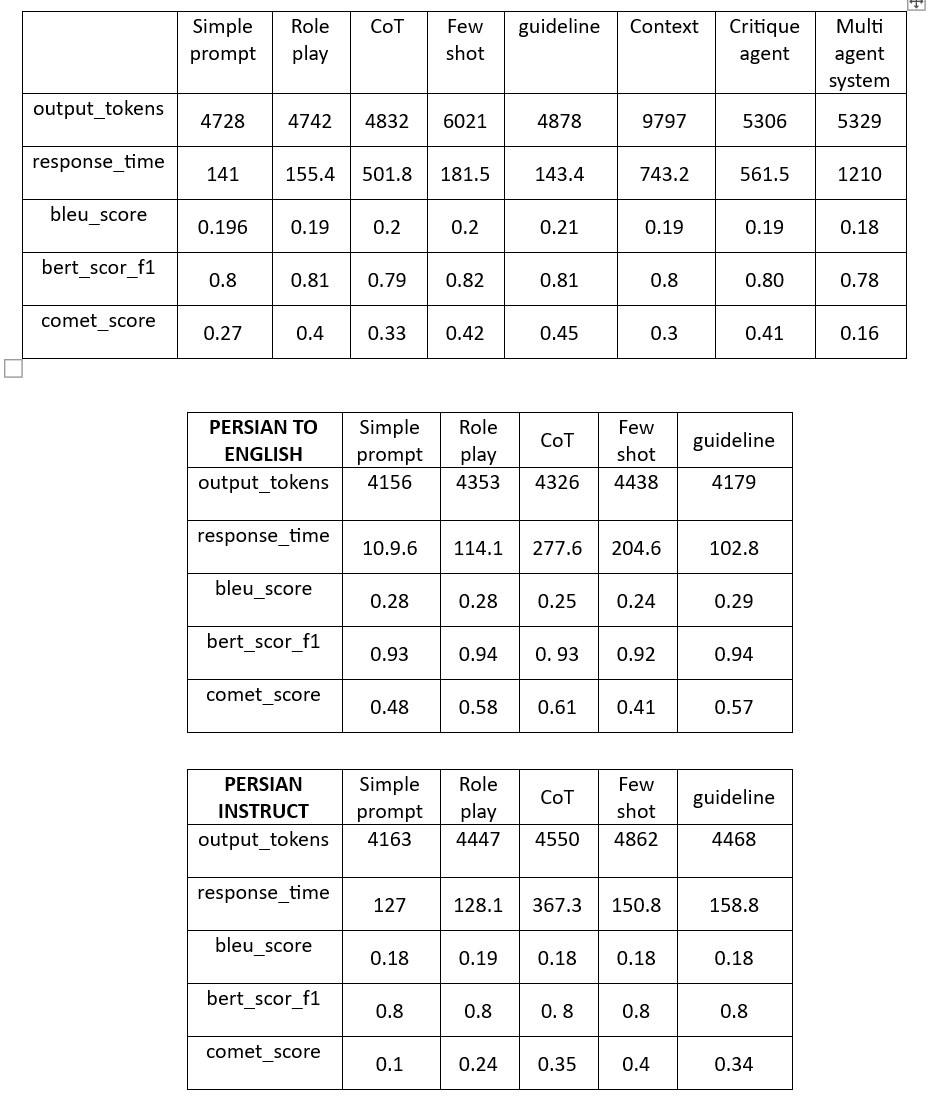

<div dir="rtl" style="font-family: Vazir; width: 85%; font-size: 16px;">
همانطور که قبلا بیان شد نتایج حالت های مختلف PERSIAN TO ENGLISH نسبت به حالت های مشابه بهتر و نتایج حالت های مختلف PERSIAN INSTRUCT نسبت به حالت های مشابه بدتر شده است. که تحلیل این نتایج قبلا بیان شده است.
<br>
اما در رابطه با مقایسه عملکرد بخش های اصلی، زمان پاسخ روش های context، CoT، Critique agent و Multi agent system در مقایسه با روش های دیگر بیشتر است. که یا بخاطر پرامپت طولانی و یا بخاطر تحلیلی که خود مدل باید انجام میداد است. Multi agent system بیشترین زمان پاسخ را دارد که بخاطر وجود چندین عامل است و همچنین مقدار سایر معیارهای این روش کم است و حتی بدتر از simple prompt است. پس این روش، روش خوبی نیست. مقدار معیارهای روش CoT هم در مقایسه با سایر روش ها کمتر است، که می تواند به این دلیل باشد فرایند تفکر به صورت انگلیسی است ولی متن موردنظر فارسی است. پس این روش نیز خوب نیست. مقدار معیارهای Critique agent بالاست ولی زمان زیادی برای پاسخ صرف می کند که این یک عیب است. بهترین مقادیر معیارها و زمان پاسخ به ترتیب متعلق به دو روش guideline و Few shot است. این دو روش با دادن یک نمونه و الگو درست ثابت به مدل توانسته اند به نتایج خوبی برسند. بنابراین این دو روش بهترین روش ها هستند. اگرچه تعریف guideline و نمونه به درستی بر روی نتایج تاثیر زیادی دارد. البته روش Role play هم انتخاب خوبی است که با یک پرامپت نسبتا ساده به نتایج بسیار خوبی رسیده است.
